# EURNOK/EURSEK — independent-day strategies

This notebook (`m-noksek.ipynb`) is one of the **primary** monthly drivers in `code/notebooks/` (`m-*.ipynb`), alongside `m-audnzd.ipynb` and `m-gbpeur.ipynb`.

Fit and back-test of the four strategies from the paper on the EURNOK/EURSEK cointegration spread, run **independently per trading day** across three calendar months configured as `MONTHS`: **August 2024** (`202408`), **December 2024** (`202412`), and **April 2025** (`202504`), evaluated in that array order (paper §2).

## Pipeline (paper §2–§4)

1. **Mid-price** (paper eq. 1): for each leg $x \in \{A,B\}$,
   $$M_t^{x} \;=\; \tfrac{1}{2}\bigl(B_t^{x} + A_t^{x}\bigr).$$
2. **Half-spread in bps** (paper eq. 2):
   $$\mathrm{HS}_t^{\,x} \;=\; \tfrac{1}{2}\frac{A_t^{x} - B_t^{x}}{M_t^{x}}\times 10^{4},$$
   used as the per-leg slippage cost in the back-test.
3. **Pre-averaging on $L$ ticks** (paper eq. 2.2 / Jacod 2017): bid/ask streams of both legs are union-aligned and forward-filled at tick level, then every block of $L=500$ synchronised ticks is collapsed into one bar by averaging the mids. Same $L$ and same boundaries on both legs, so the pre-averaged legs stay perfectly co-timed.
4. **Rolling cointegration** (paper §3.1, eqs. 4–7): on the pre-averaged log prices, the hedge ratio $\beta_t$ and intercept $\alpha_t$ are estimated by rolling OLS with window $W_\beta=25$,
   $$S_t \;=\; \log P_t^{\mathrm{mid},A} - \beta_t \log P_t^{\mathrm{mid},B} - \alpha_t,\qquad
     \Delta S_t \;=\; r_t^{A} - \beta_{t-1}\, r_t^{B}.$$
5. **Rolling $z$-score** (paper §3.2, eq. 8): over a window $W_z=15$,
   $$Z_t \;=\; \frac{S_t - \mu_t^{S}}{\sigma_t^{S}}.$$
6. **MS-AR(1) on the spread** (paper §4.3, eqs. 15–18): with $K=2$ latent regimes,
   $$S_t \mid S_{t-1}, K_t = k \;\sim\; \mathcal{N}\!\bigl(c^{(k)} + \rho^{(k)} S_{t-1},\; (\sigma^{(k)})^{2}\bigr),$$
   fit by EM (Baum–Welch, paper §4.5) with multi-seed init. Before estimation the spread is winsorised at $\mathrm{median}(S)\pm 4\,\mathrm{std}(S)$ and rescaled by $10^{4}$ (paper §4.3).
7. **Regime labelling by innovation variance** (paper §4.7, eq. 21):
   $$k_{\mathrm{MR}} = \arg\min_{k}\sigma^{(k)},\qquad k_{\mathrm{DR}} = \arg\max_{k}\sigma^{(k)},$$
   with smoothed posteriors $\gamma_t^{\mathrm{MR}} = \mathbb{P}(K_t=k_{\mathrm{MR}}\mid S_1,\ldots,S_T)$ and $\gamma_t^{\mathrm{DR}} = 1 - \gamma_t^{\mathrm{MR}}$.

## The four strategies

All four share the same spread $S_t$ and rolling $z$-score $Z_t$ as inputs; they differ only in **whether and how** $\gamma_t^{\mathrm{MR}}$ enters the rule (paper §4.8, Table "Strategy definitions").

| # | Strategy | Always long? | Entry threshold | Gate $G_t$ | Reads HMM? |
|---|---|---|---|---|---|
| **(1)** | **Buy & Hold** | Yes — $\pi_t^{\mathrm{BH}}=+1$ | — | — | No |
| **(2)** | **Baseline** | No | $z_q$ | $1$ | No |
| **(3)** | **AR** | No | $z_q$ | $\mathbf{1}\{\gamma_t^{\mathrm{MR}} \geq 1-\delta\}$ | Yes, **binary** |
| **(4)** | **MS-AR** | No | $z_q^{\mathrm{eff}}(t) = \gamma_t^{\mathrm{MR}}\, z_q + \gamma_t^{\mathrm{DR}}\, z_v$ | $1$ | Yes, **continuous** |

**(1) Buy & Hold** earns $\Delta S_t$ at every bar with zero costs — passive drift reference.

**(2) Baseline** position rule (paper eq. 25):
$$\pi_t = \begin{cases}+1 & \pi_{t-1}=0,\; Z_t < -z_q \\ -1 & \pi_{t-1}=0,\; Z_t > +z_q \\ 0 & \pi_{t-1}\neq 0,\; |Z_t| \leq z_x \\ \pi_{t-1} & \text{otherwise.}\end{cases}$$

**(3) AR** uses the same direction as Baseline but adds a **binary danger gate** (paper eqs. 27–28). If $\gamma_t^{\mathrm{MR}} < 1-\delta$, any open position is liquidated and no new entries are taken until the gate re-opens.

**(4) MS-AR** keeps the gate at 1 but **widens** the entry threshold continuously with $\gamma_t^{\mathrm{DR}}$ (paper eqs. 29–30): in the MR-dominated regime $z_q^{\mathrm{eff}}\to z_q$ and the rule trades like the Baseline; in the DR-dominated regime $z_q^{\mathrm{eff}}\to z_v \geq z_q$, requiring a larger deviation before entering.

## Per-bar transaction costs (paper §2.11 / §5.1)

Every position flip pays the fixed commission `fee_bps` plus, when `slippage_mode='half_spread'`, the round-trip cost $\mathrm{HS}^{A}_t + \mathrm{HS}^{B}_t$ in bps (the combined cross-the-spread cost for both legs).

> The OOS forward filter is intentionally deferred — the strategies are fed the **in-sample smoothed posteriors** $\gamma_t^{\mathrm{MR}}$ (paper §4.7), so the back-test is a *best-case* picture of how the regime information would be used if it were known. The walk-forward extension lives in `code/notebooks/Y-*.ipynb`.

---

In [2]:
# Colab bootstrap (silently skipped on local environments).
import importlib.util, sys, os
if importlib.util.find_spec('google.colab') is not None:
    import subprocess
    subprocess.run(
        ['curl', '-sL',
         'https://raw.githubusercontent.com/egil10/stk-mat2011/main/code/scripts/colab.py',
         '-o', '/content/colab.py'],
        check=True,
    )
    sys.path.insert(0, '/content')
    from colab import setup
    setup('code/notebooks')
else:
    sys.path.insert(0, os.path.abspath('../notebooks'))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD           : /content/stk-mat2011/code/notebooks
Scripts path  : /content/stk-mat2011/code/scripts
Data symlink  : /content/stk-mat2011/code/data/processed -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/data/processed
Parquet files : 916


In [3]:
%pip install --quiet arch statsmodels numba optuna


In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from spread import SPREAD
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

PAIR_A, PAIR_B = 'EURNOK', 'EURSEK'
MONTHS         = ['202412', '202408', '202504']
DATA_DIR       = '../data/processed'

# Tick-synced pre-averaged bars (paper eq 2.2).
# L=500 -> each bar is the mean of 500 SYNCHRONISED ticks on both legs.
# Tradeoff vs L=200: 2.5x fewer bars/day -> 2.5x fewer trades -> 2.5x less
# cumulative cost erosion; alpha per trade is unchanged.
BAR_CFG = dict(
    agg_type     = 'tick',
    threshold    = 500,       # block size L
    price_agg    = 'mean',    # 'mean' triggers tick-sync + pre-averaging
    active_hours = (0, 24),
)

# Per-day fit. n_init=5 gives the EM five random seeds; rescues most
# post-holiday low-liquidity days where a single seed lands in a saddle
# and the SVD fails to converge (paper §4.5 multi-seed Baum-Welch).
FIT_CFG = dict(
    coint_window  = 25,    # W_beta  (was 50 at L=200)
    z_window      = 15,    # W_z     (was 25 at L=200)
    k_regimes     = 2,
    winsorize_std = 4.0,
    scaling       = 10000,
    n_init        = 5,     # was 3 — bumped to rescue HMM SVD non-convergence
)

# Strategies. z_q widened to 2.0 to cut entry rate roughly in half
# (the binding constraint at this bar resolution is cost-per-trade).
# fee_bps = 0.05 ~= $5 per $1M USD notional, the institutional ECN /
# prime-brokerage spot-FX brokerage rate. Dukascopy retail is ~0.35 bps
# (JForex $35/M) to 0.50 bps (MT4 $50/M); we model best-case institutional
# execution since the half-spread (paper eq. 2) is the binding cost anyway.
STRAT_CFG = dict(
    z_quiet          = 2.0,    # was 1.3
    z_volatile       = 3.0,    # widened in tandem with z_quiet
    exit_z           = 0.0,
    danger_threshold = 0.30,
    fee_bps          = 0.05,
    slippage_mode    = 'half_spread',
    flatten_eod      = True,
    prob_smoothing   = 0,
)

# Sharpe annualisation is computed per run as 252 * (n_bars / n_days) in the
# cross-month summary cell, so the magnitude matches the actual sampling
# frequency on each (pair, month) instead of assuming minute bars.

## Per-month run

For each month we

1. Aggregate raw bid/ask ticks into $L$-tick pre-averaged bars (`SPREAD`, paper eq. 2.2).
2. Fit each trading day independently — rolling cointegration $(\beta_t, \alpha_t)$ with window $W_\beta$ (paper §3.1), rolling $z$-score with window $W_z$ (paper §3.2), MS-AR(1) on the day's spread with $K=2$ via EM/Baum–Welch (paper §4.3–§4.5). Regimes are labelled by innovation variance $\sigma^{(k)}$ (paper §4.7).
3. Run **(1) Buy & Hold**, **(2) Baseline (z-score, paper eq. 25)**, **(3) AR (binary $\gamma^{\mathrm{MR}}$-gate, paper eqs. 27–28)**, **(4) MS-AR (dynamic $\gamma$-weighted entry threshold, paper eqs. 29–30)** through the same back-test (`BACKTESTER`), with half-spread + fee costs (paper §2.11).
4. Score with `TEARSHEET` and print the four-column tearsheet (BuyHold | Baseline | AR | MS_AR).

---

In [5]:
def files(pair, month):
    p = pair.lower()
    return (
        [f'{DATA_DIR}/{p}_dukascopy_ask_{month}.parquet'],
        [f'{DATA_DIR}/{p}_dukascopy_bid_{month}.parquet'],
    )


def fmt_pnl(bt):
    return {s: bt[f'Return_{s}'].fillna(0).sum() * 1e4
            for s in ['BuyHold', 'Baseline', 'AR', 'MS_AR']}


runs = {}
for m in MONTHS:
    print(f'\n=== {m}  {PAIR_A}/{PAIR_B} ===')

    ask_a, bid_a = files(PAIR_A, m)
    ask_b, bid_b = files(PAIR_B, m)

    df = SPREAD(**BAR_CFG).build([ask_a, bid_a, ask_b, bid_b], verbose=True)
    n_bars = len(df)
    n_days = df.index.normalize().unique().shape[0]
    print(f'  {n_bars:,} pre-averaged bars over {n_days} trading days')

    fitted, params = ENGINE.each_day(df, **FIT_CFG, verbose=True)
    bt = BACKTESTER(fitted).run(**STRAT_CFG)
    runs[m] = (bt, params, fitted)

    pnl = fmt_pnl(bt)
    bh, base, ar, ms = pnl['BuyHold'], pnl['Baseline'], pnl['AR'], pnl['MS_AR']
    print(
        f'  net pnl (bps):  BH={bh:+8.1f}  Base={base:+8.1f}  '
        f'AR={ar:+8.1f}  MS-AR={ms:+8.1f}'
    )



=== 202412  EURNOK/EURSEK ===
built 10690 pre-averaged bars (L=500 synced ticks/block, 5,345,508 synced ticks total)
  10,690 pre-averaged bars over 22 trading days
Each-day fit | coint_window=25 | z_window=15 | k_regimes=2 | winsor=4.0σ | scale=x10000 | n_init=5 | days=22
  2024-12-25: skipped (17 bars, need ≥50)
  -> 21/22 days fitted (1 too short, 0 HMM failures)
  net pnl (bps):  BH=   +60.6  Base= -4473.8  AR= -1592.8  MS-AR= -2070.8

=== 202408  EURNOK/EURSEK ===
built 14841 pre-averaged bars (L=500 synced ticks/block, 7,421,239 synced ticks total)
  14,841 pre-averaged bars over 22 trading days
Each-day fit | coint_window=25 | z_window=15 | k_regimes=2 | winsor=4.0σ | scale=x10000 | n_init=5 | days=22
  -> 22/22 days fitted (0 too short, 0 HMM failures)
  net pnl (bps):  BH=  -148.5  Base= -6277.4  AR= -1816.7  MS-AR= -2490.5

=== 202504  EURNOK/EURSEK ===
built 26129 pre-averaged bars (L=500 synced ticks/block, 13,065,398 synced ticks total)
  26,129 pre-averaged bars over 22 

## Engle-Granger cointegration screener (per month)

For each evaluation month, run the same Engle-Granger / rolling-OLS / half-life diagnostic that the `Y-*.ipynb` walk-forward notebooks use (`SCREENER`), but applied **per month** instead of over the full 24-month panel. The screener emits a 3-panel figure (rolling p-value, rolling half-life, rolling hedge ratio) saved as `<PAIR>_<MONTH>_cointegration_screener.pdf` next to the tearsheet PDFs in `PAIR_DIR`.

This is a pure data-sanity step — it does not feed back into the strategies; it just documents how mean-reverting the pair is during each evaluation window.


Cointegration PDFs -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK
============================  202412  ============================

=== COINTEGRATION SCREENER ===
Full: p=0.2909 | half-life=690.6 | β=-1.0217

Rolling (2000-bar, step 200, n=44):
  p<0.05: 4.5% | p<0.10: 6.8%
  half-life: 191.0 (IQR 158–279)
  β: 0.2394 ±0.8960 [-1.0938, 2.1371]


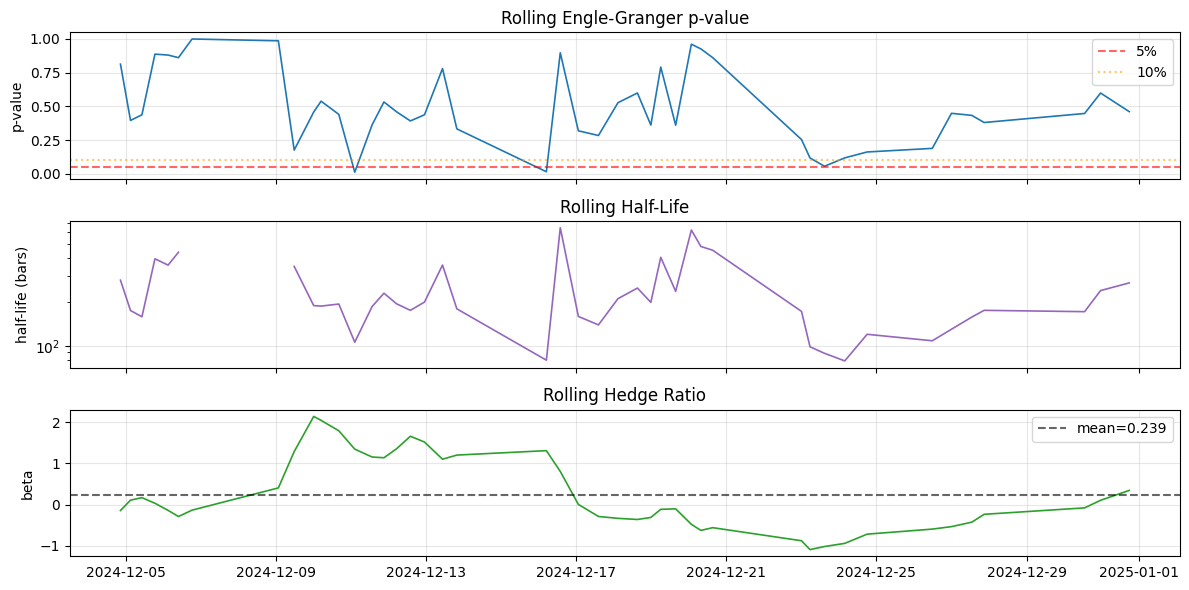

============================  202408  ============================

=== COINTEGRATION SCREENER ===
Full: p=0.4452 | half-life=1358.2 | β=1.0603

Rolling (2000-bar, step 200, n=65):
  p<0.05: 6.2% | p<0.10: 12.3%
  half-life: 129.2 (IQR 108–175)
  β: 0.7893 ±0.6505 [-0.8209, 2.0881]


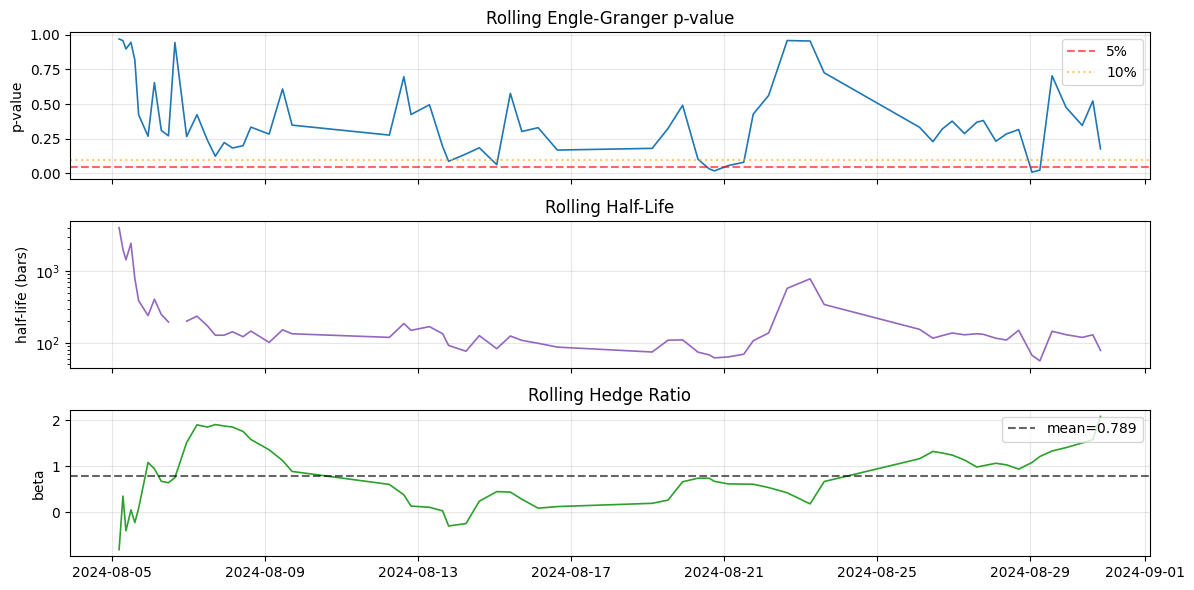

============================  202504  ============================

=== COINTEGRATION SCREENER ===
Full: p=0.0170 | half-life=670.2 | β=1.5689

Rolling (2000-bar, step 200, n=121):
  p<0.05: 23.1% | p<0.10: 41.3%
  half-life: 100.0 (IQR 49–149)
  β: 0.8746 ±0.5419 [-0.1987, 2.0936]


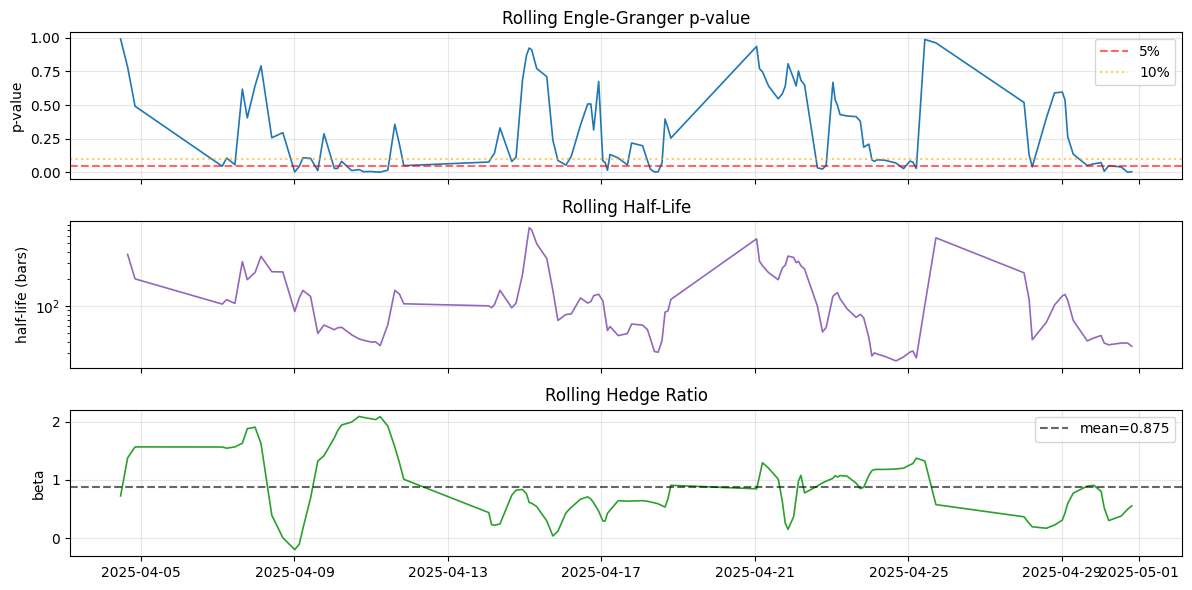

In [6]:
from pathlib import Path
import importlib, screener as _screener_mod
importlib.reload(_screener_mod)
from screener import SCREENER
from plotting import default_pdf_dir

PAIR_DIR = default_pdf_dir() / f'{PAIR_A}_{PAIR_B}'
PAIR_DIR.mkdir(parents=True, exist_ok=True)
print(f'Cointegration PDFs -> {PAIR_DIR}')

for m, (_, _, fitted) in runs.items():
    print(f'{"="*28}  {m}  {"="*28}')

    # Window/step sized to each month's bar count so even thinner months
    # (e.g. the August/December holiday weeks) still produce ~30+ rolling points.
    n = len(fitted)
    rw   = max(200, min(2000, n // 5))
    step = max(20, rw // 10)

    sc = SCREENER(
        fitted['Asset_A'],
        fitted['Asset_B'],
        save_pdf   = True,
        pdf_dir    = str(PAIR_DIR),
        pdf_prefix = f'{PAIR_A}_{PAIR_B}_{m}',
    )
    sc.generate_report(rolling_window=rw, rolling_step=step)


## Per-month tearsheets

Combined dashboards print to the cell output. Every panel is **also** saved as its own PDF so individual figures are ready to drop into the thesis. PDFs land in `plots/<PAIR>/` (Drive on Colab, `./plots/` locally).


PDFs -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK
============================  202412  ============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | 60.58          | -4473.83       | -1592.84       | -2070.78       |
Annual Return (bps)            | 763.03         | -56347.12      | -20061.51      | -26081.12      |
Best Month (bps)               | 60.58          | -4473.83       | -1592.84       | -2070.78       |
Worst Month (bps)              | 60.58          | -4473.83       | -1592.84       | -2070.78       |
Positive Months %              | 100.00%        | 0.00%          | 0.00%          | 0.00%          |

--- RISK ---
Annual Volatility (bps)        

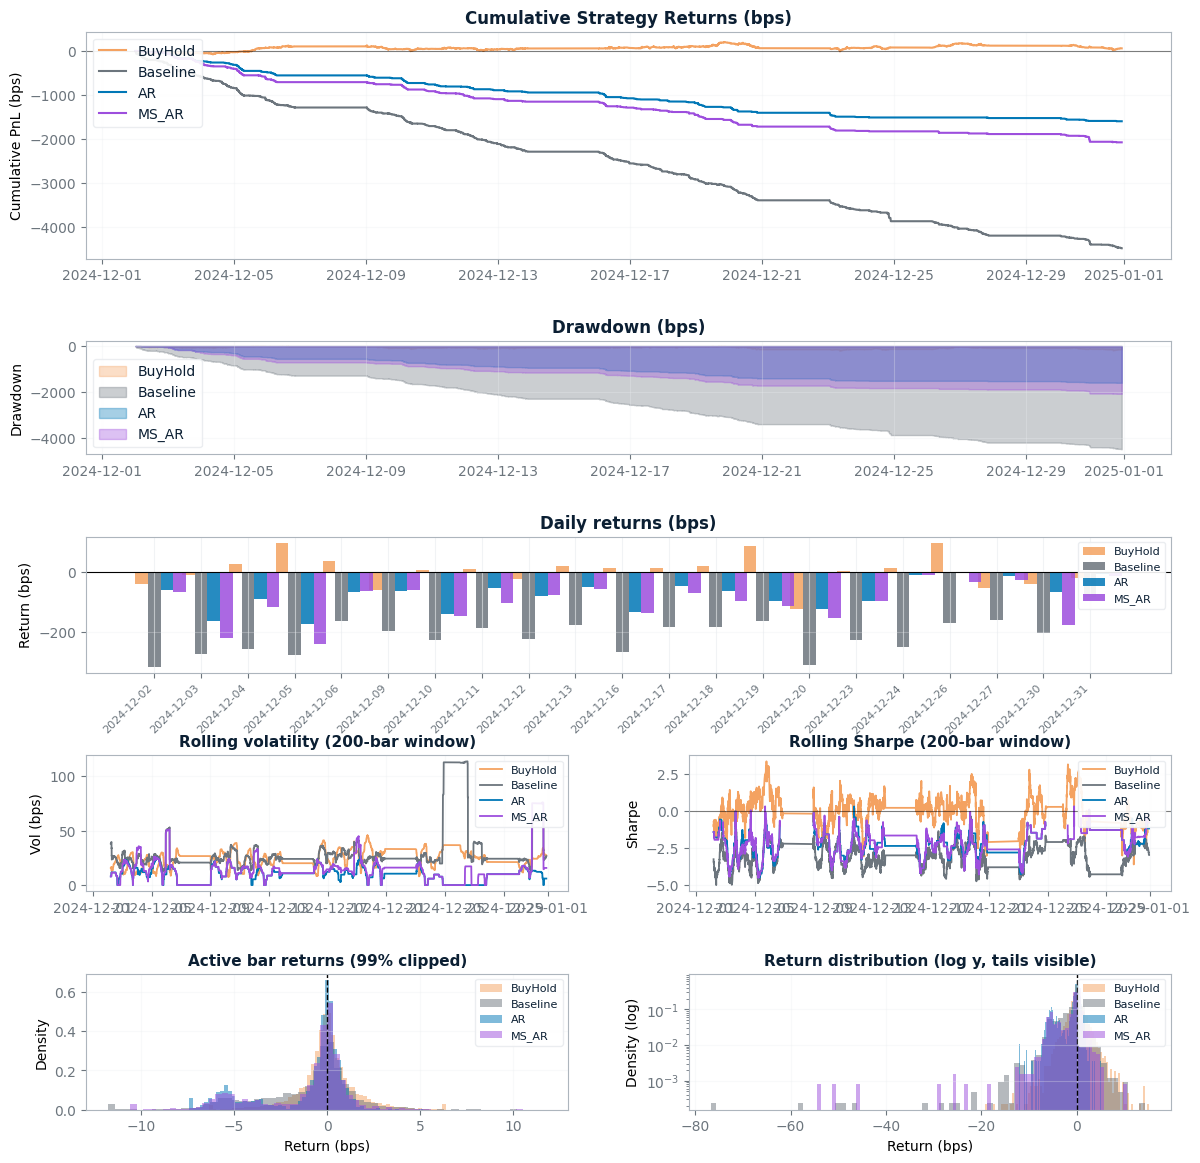

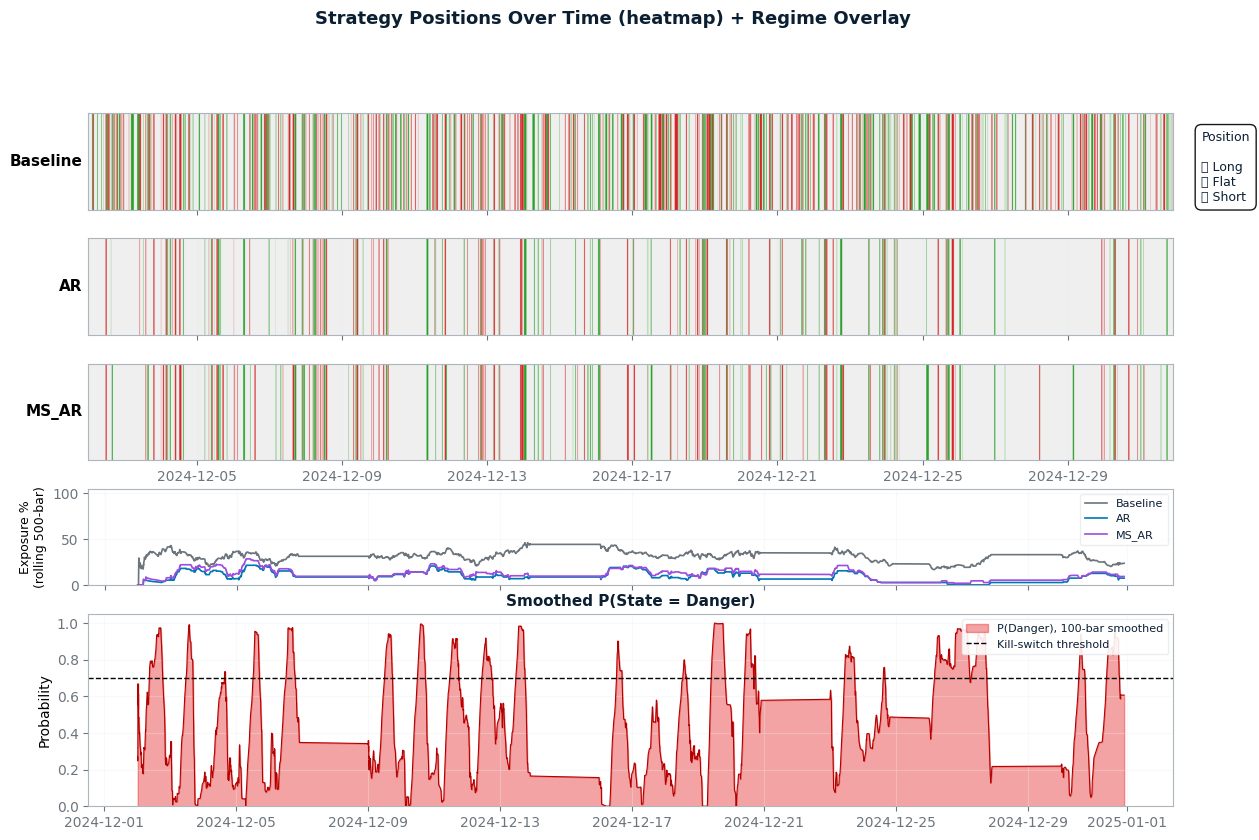

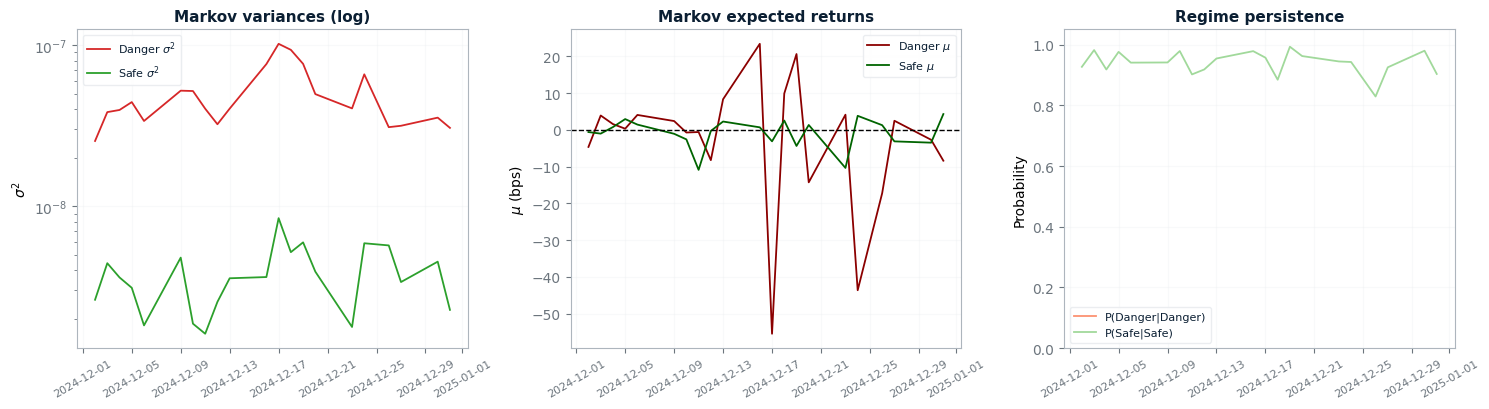

============================  202408  ============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | -148.51        | -6277.42       | -1816.72       | -2490.51       |
Annual Return (bps)            | -1870.45       | -79062.97      | -22881.30      | -31367.54      |
Best Month (bps)               | -148.51        | -6277.42       | -1816.72       | -2490.51       |
Worst Month (bps)              | -148.51        | -6277.42       | -1816.72       | -2490.51       |
Positive Months %              | 0.00%          | 0.00%          | 0.00%          | 0.00%          |

--- RISK ---
Annual Volatility (bps)        | 904.87         | 1226.06        | 501.14         | 836.51         |
Max Draw

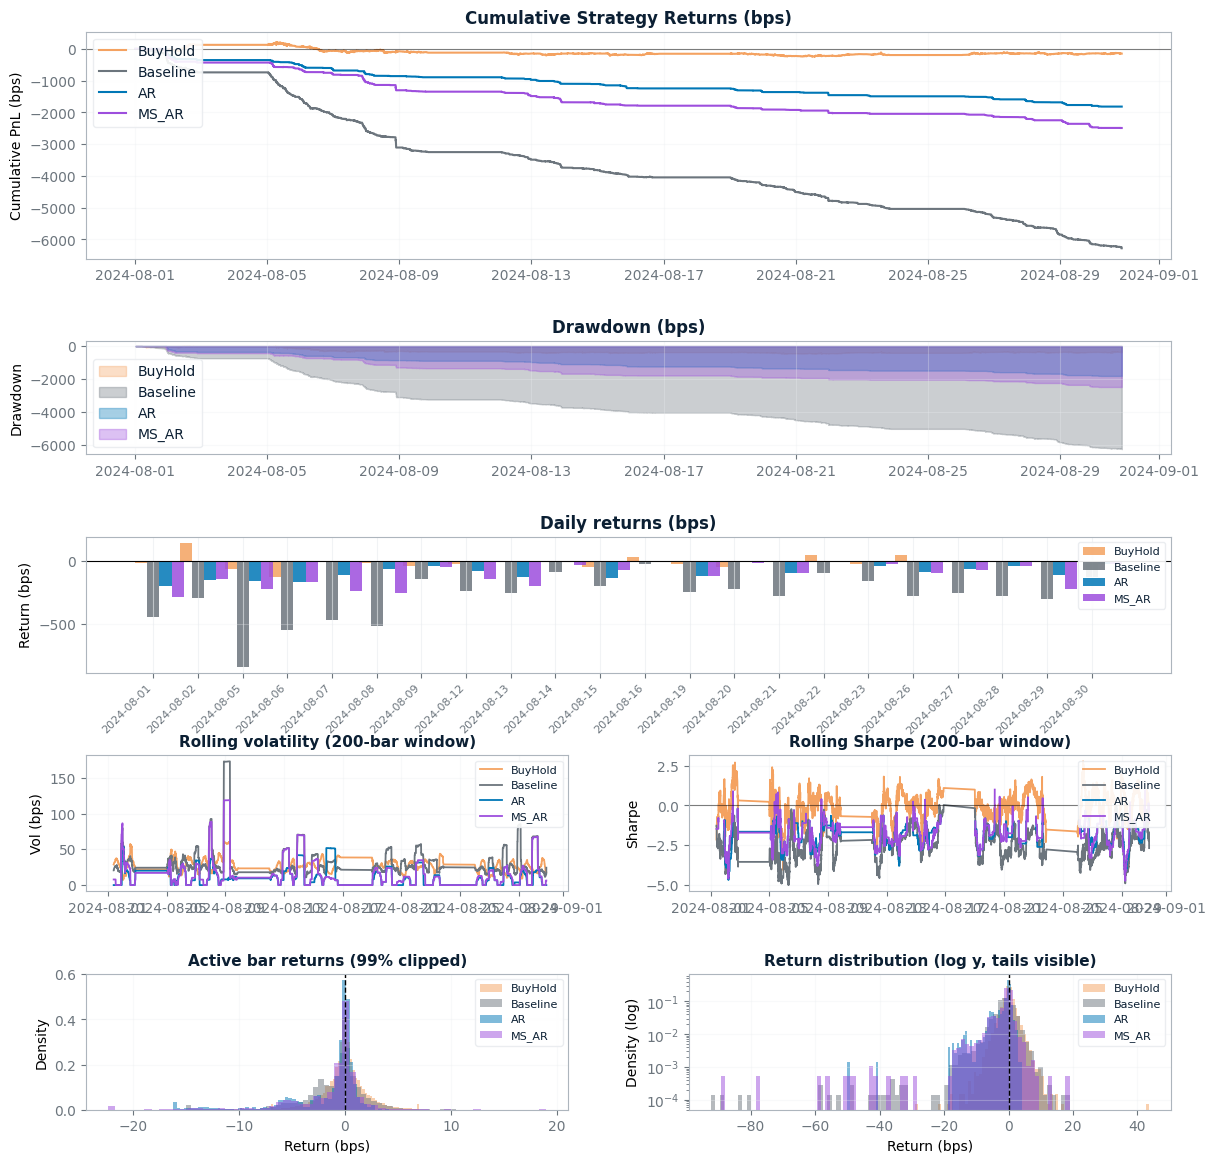

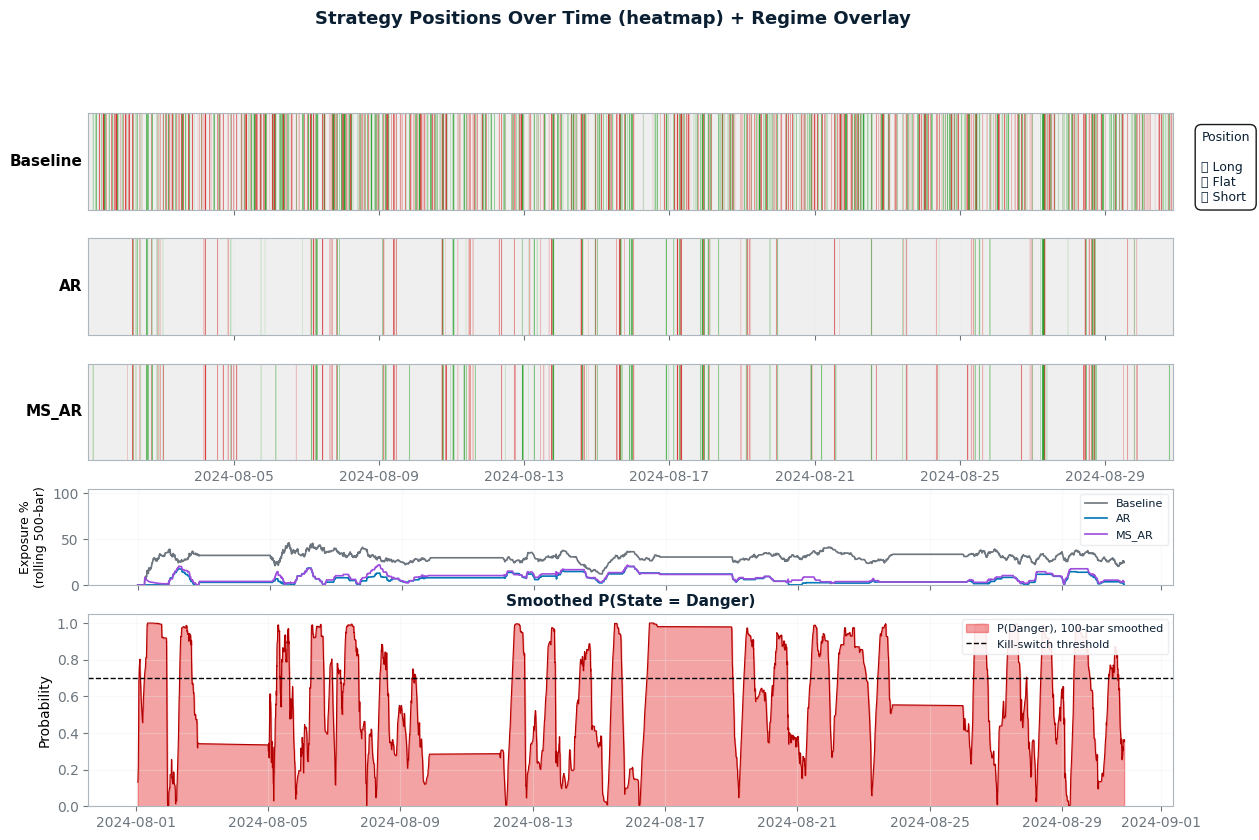

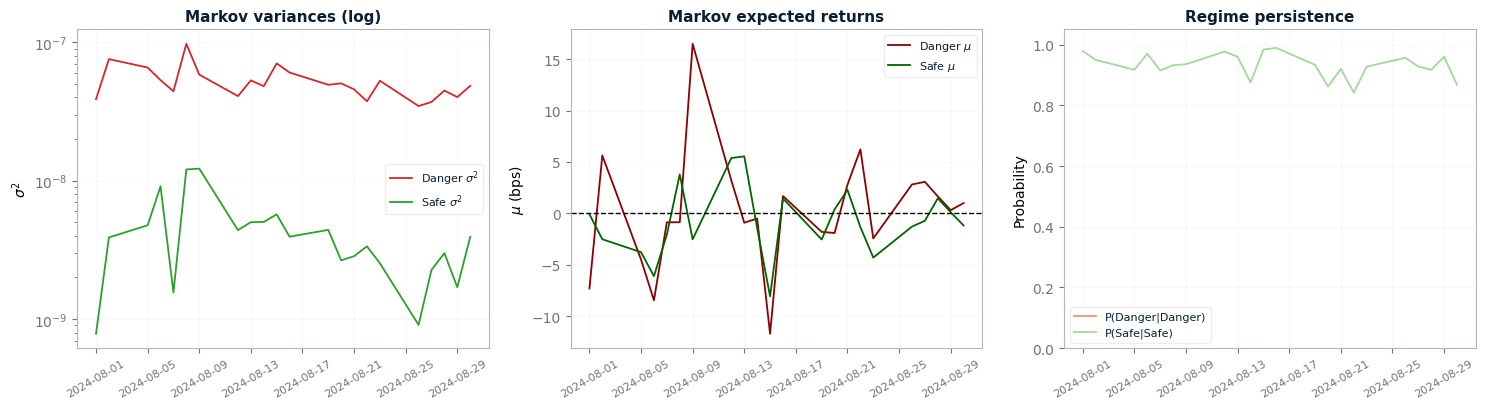

============================  202504  ============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | 527.70         | -19906.39      | -8103.49       | -9487.28       |
Annual Return (bps)            | 6646.26        | -250717.51     | -102062.01     | -119490.65     |
Best Month (bps)               | 527.70         | -19906.39      | -8103.49       | -9487.28       |
Worst Month (bps)              | 527.70         | -19906.39      | -8103.49       | -9487.28       |
Positive Months %              | 100.00%        | 0.00%          | 0.00%          | 0.00%          |

--- RISK ---
Annual Volatility (bps)        | 1508.79        | 1988.38        | 973.31         | 1143.00        |
Max Draw

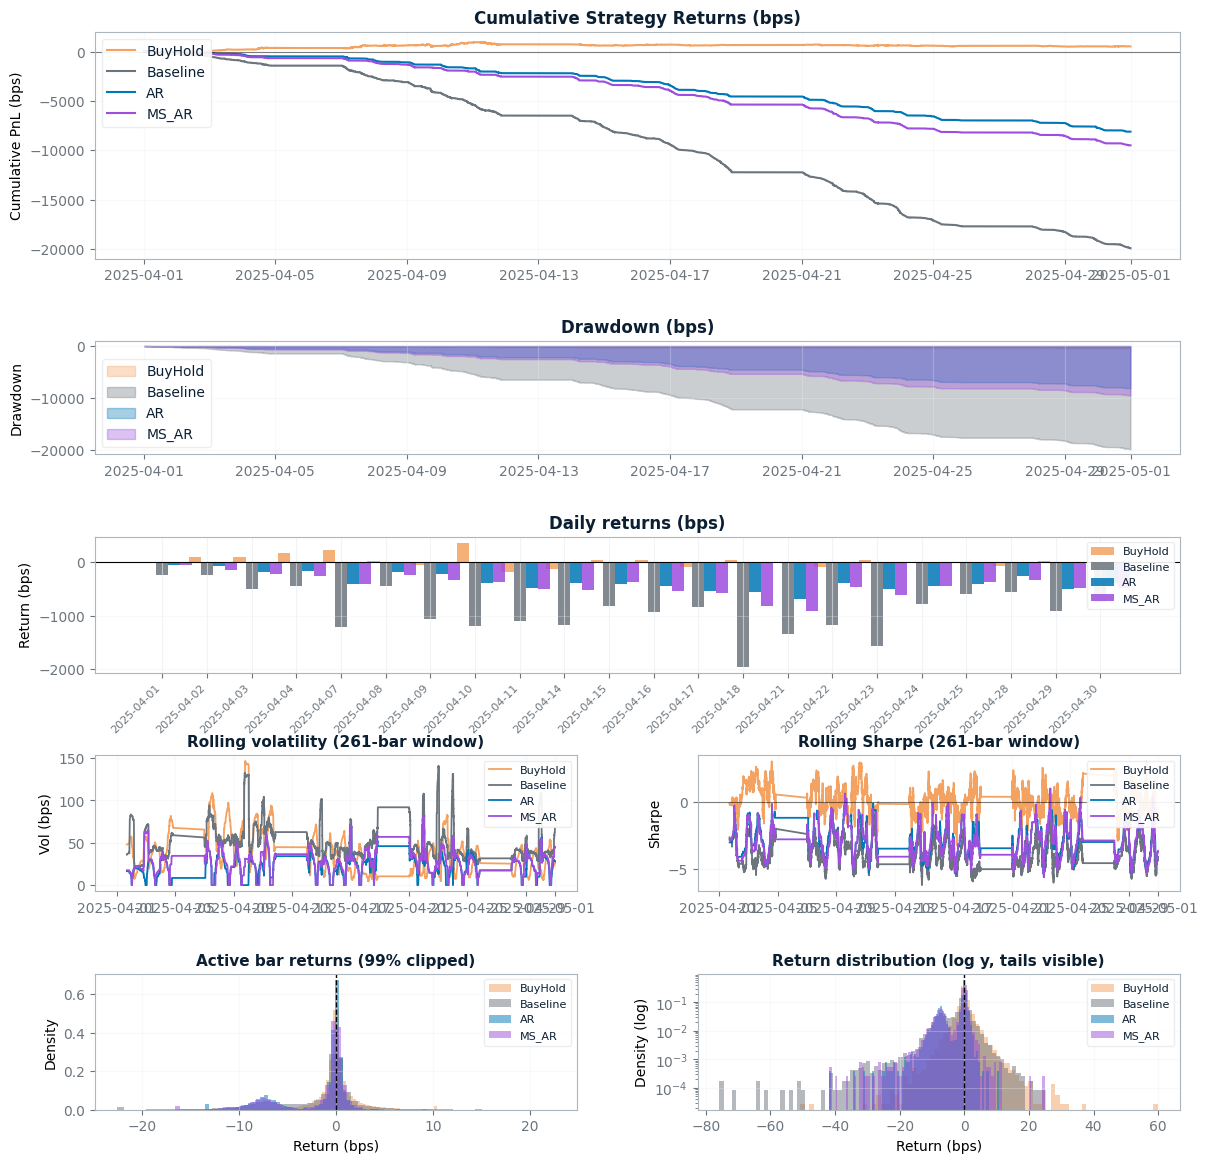

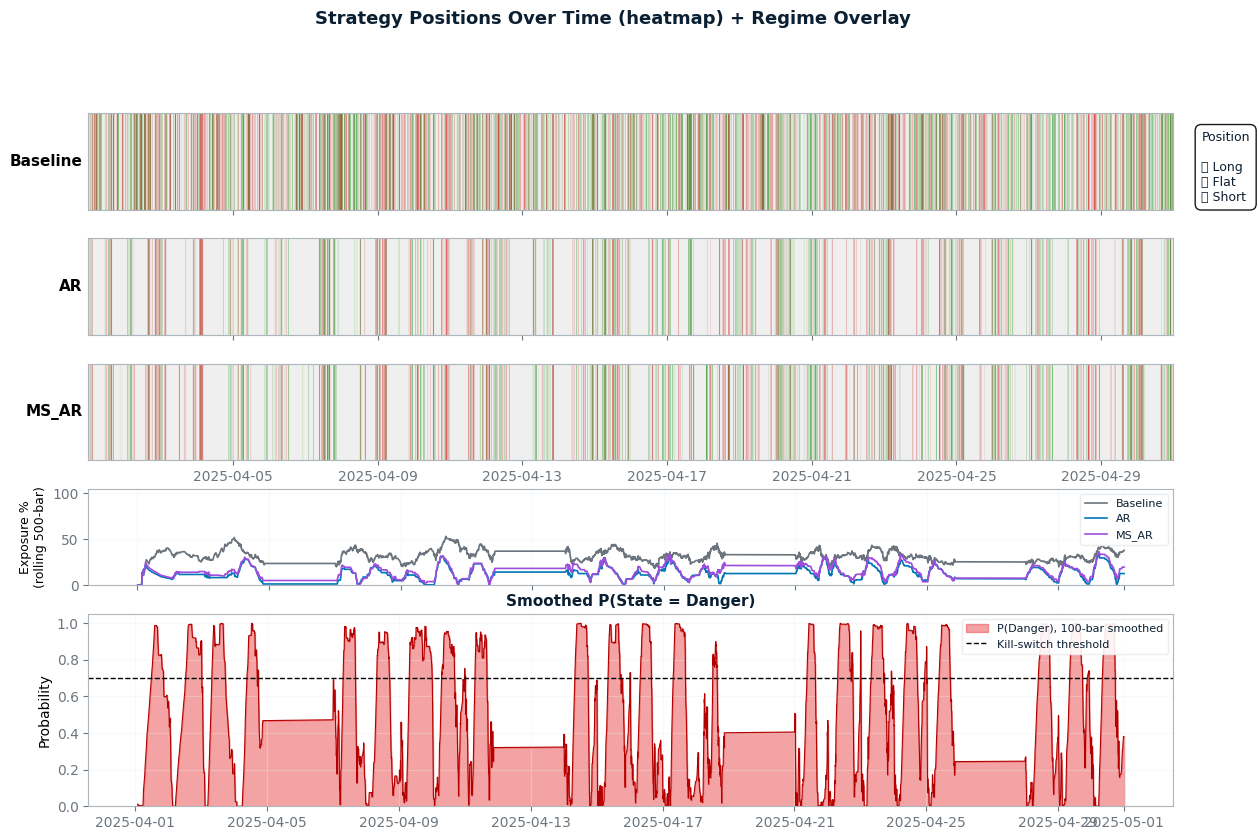

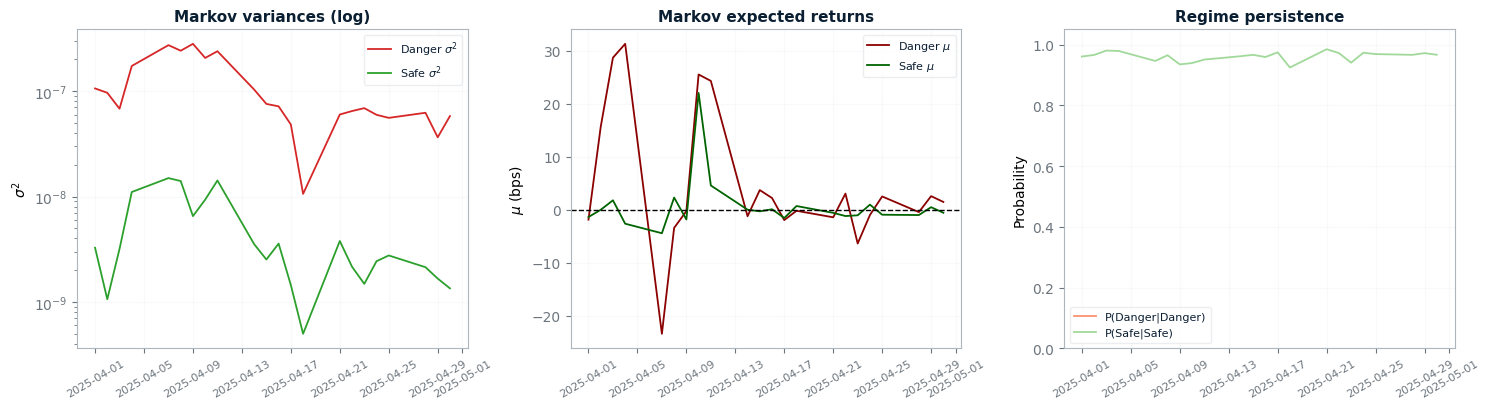

In [7]:
from pathlib import Path
from plotting import default_pdf_dir

PAIR_DIR = default_pdf_dir() / f'{PAIR_A}_{PAIR_B}'
PAIR_DIR.mkdir(parents=True, exist_ok=True)
print(f'PDFs -> {PAIR_DIR}')

for m, (bt, params, _) in runs.items():
    print(f'{"="*28}  {m}  {"="*28}')
    try:
        ts = TEARSHEET(
            bt,
            df_params  = params,
            save_pdf   = True,
            pdf_dir    = str(PAIR_DIR),
            pdf_prefix = f'{PAIR_A}_{PAIR_B}_{m}',
        )
        ts.generate_report()

        # Render the combined dashboards FIRST so BuyHold + all panels show
        # even if the per-panel PDF saves below blow up for any reason.
        try:
            ts.plot_performance()
        except Exception as e:
            print(f'  [plot_performance failed: {type(e).__name__}: {e}]')
        try:
            ts.plot_positions_and_regimes()
        except Exception as e:
            print(f'  [plot_positions_and_regimes failed: {type(e).__name__}: {e}]')
        try:
            ts.plot_markov_dynamics()
        except Exception as e:
            print(f'  [plot_markov_dynamics failed: {type(e).__name__}: {e}]')

        # Then save each panel as its own PDF (newer tearsheet only).
        # Wrapped separately so a missing method on an older tearsheet
        # cannot suppress the dashboards above.
        if hasattr(ts, 'save_individual_perf_panels'):
            try:
                ts.save_individual_perf_panels()
            except Exception as e:
                print(f'  [save individual perf panels failed: {type(e).__name__}: {e}]')
        if hasattr(ts, 'save_individual_markov_panels'):
            try:
                ts.save_individual_markov_panels()
            except Exception as e:
                print(f'  [save individual markov panels failed: {type(e).__name__}: {e}]')
    except Exception as e:
        print(f'  [{m} fully failed: {type(e).__name__}: {e}]')

## Cross-month summary

PnL is pooled across the three `MONTHS` evaluation windows (**August 2024**, **December 2024**, **April 2025**, processed in array order).

PnL in bps, Sharpe annualised on the **per-run** tick-clock (`252 × bars-per-day`, computed individually per month/pair so the scaling matches the actual sampling frequency), and one round-trip per `Target` flip cycle. The previous global factor `252 × 24 × 60 = 363 k` assumed minute bars and overstated the Sharpe magnitudes by `√(1440 / bpd)` ≈ 2–2.4× at $L=500$.

## 3-month stacked equity curves (one figure, four strategies)

Single wide figure with the three months stacked top-to-bottom. Each subplot is the cumulative bps PnL of the **four strategies** for that month so the same y-axis-style comparison is repeated on **August 2024**, **December 2024**, and **April 2025** (`MONTHS`).

Artifacts land under `PAIR_DIR` from the tearsheet cell:

- **Linear y** (unchanged filenames): `<slug>_three_month_strategy_panel.pdf` and `<slug>_<MONTH>_strategy_panel.pdf`.
- **Symmetric log-y** (`symlog`): same stems with `_symlog` before `.pdf` — compresses huge losses so other curves are readable.
- **Normalized ±100** (`norm100`): each strategy scaled independently around index **100** using its max cumulative excursion — purely visual shape comparison on shared axes.
- **Individual overlays**: `<slug>_<StrategyKey>_by_month_overlay.pdf` (plus `_symlog` / `_norm100`), one PDF per strategy with evaluation months overlaid; **x-axis is fraction through month** (0→1) so bar clocks align across months.



saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_three_month_strategy_panel.pdf


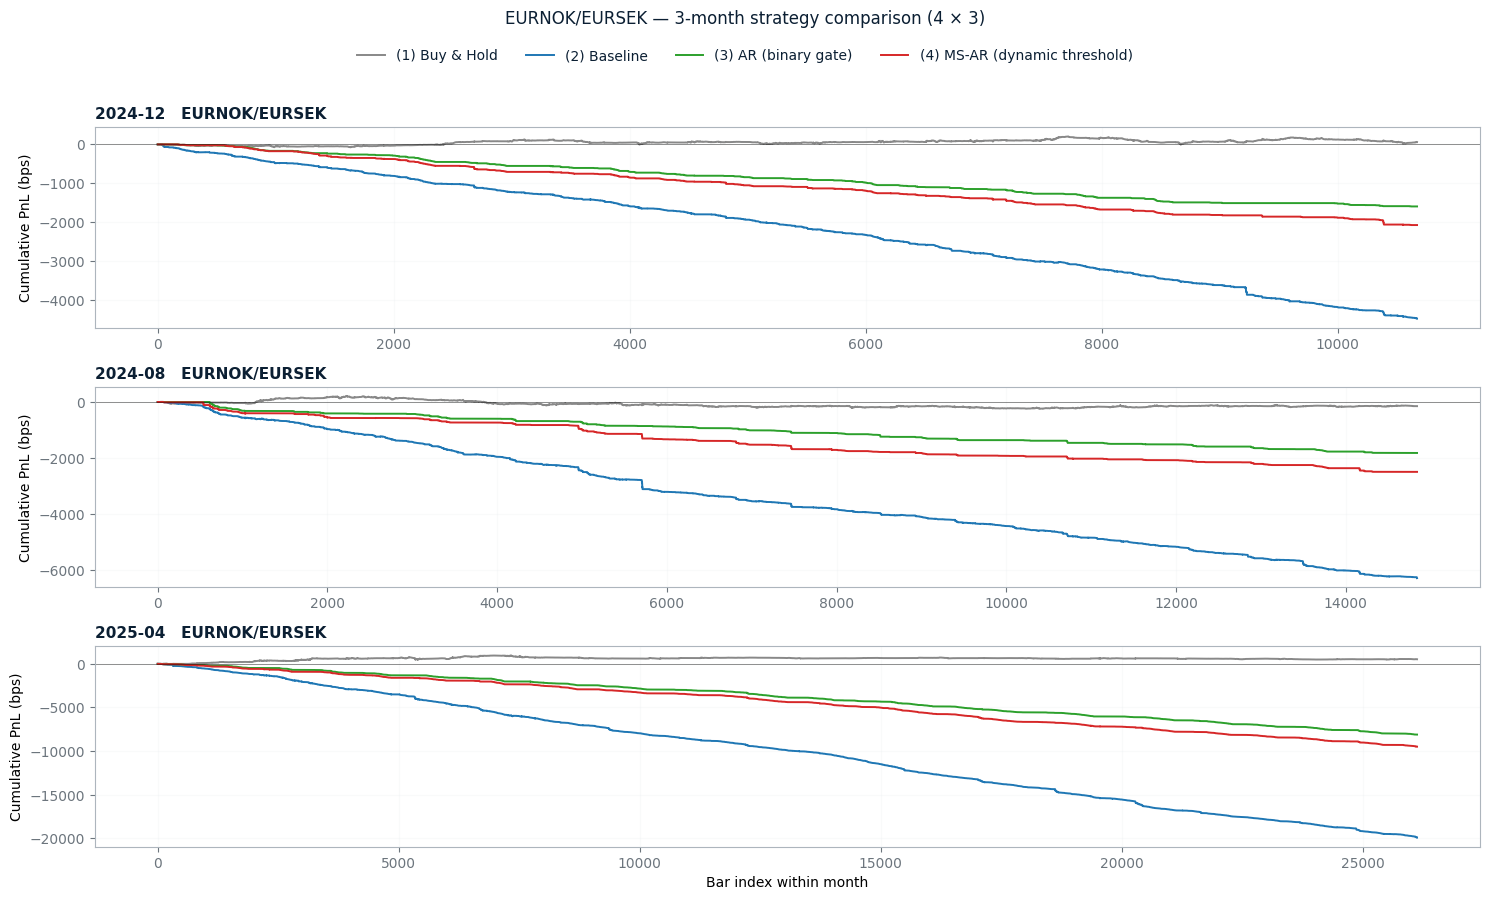

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_three_month_strategy_panel_symlog.pdf


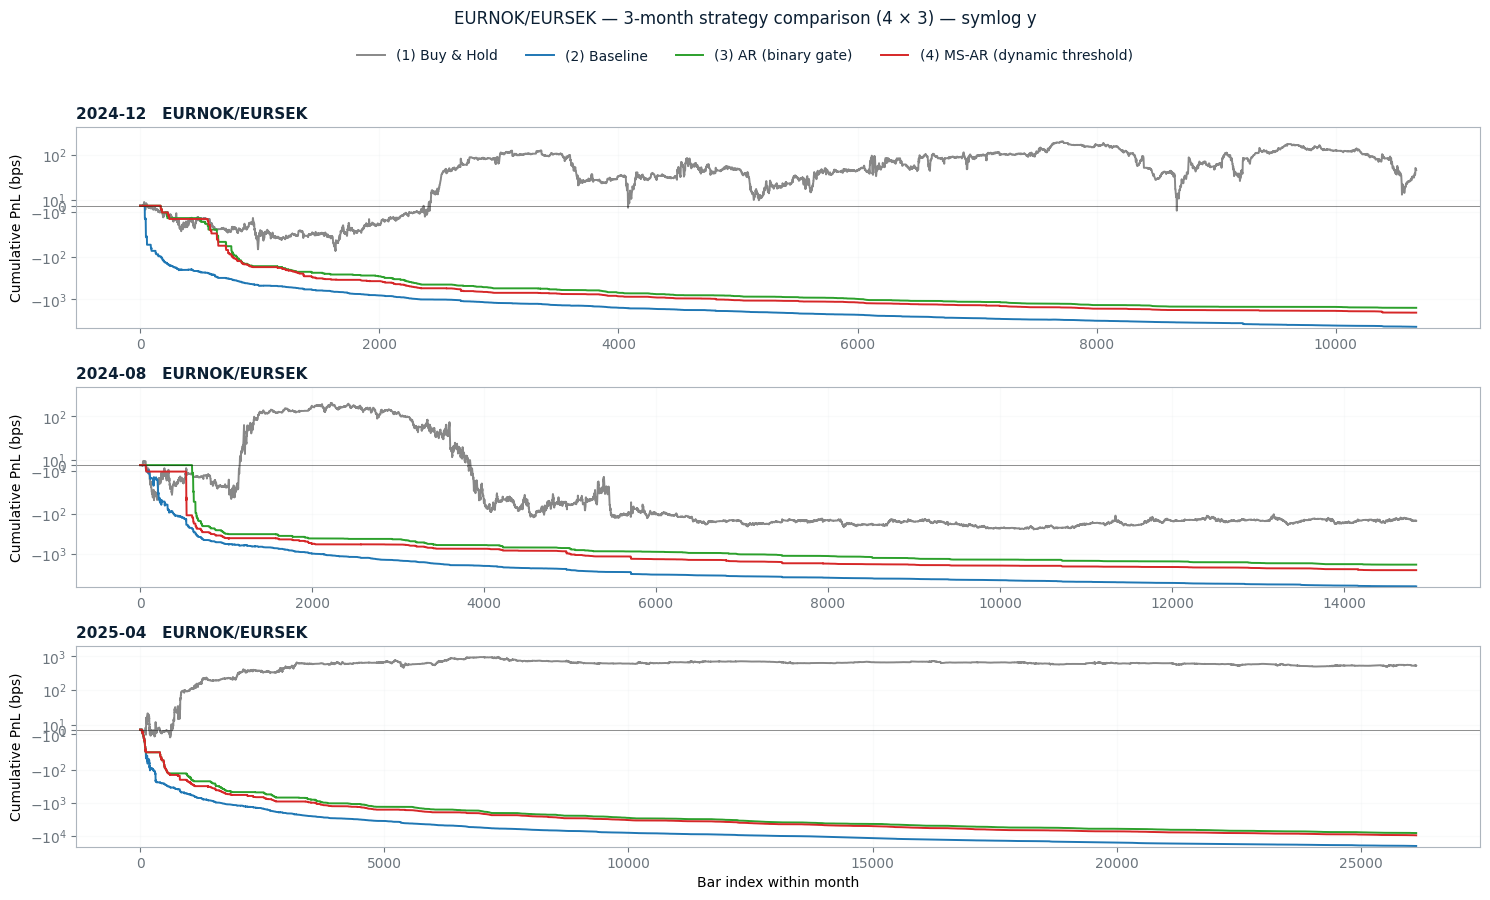

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_three_month_strategy_panel_norm100.pdf


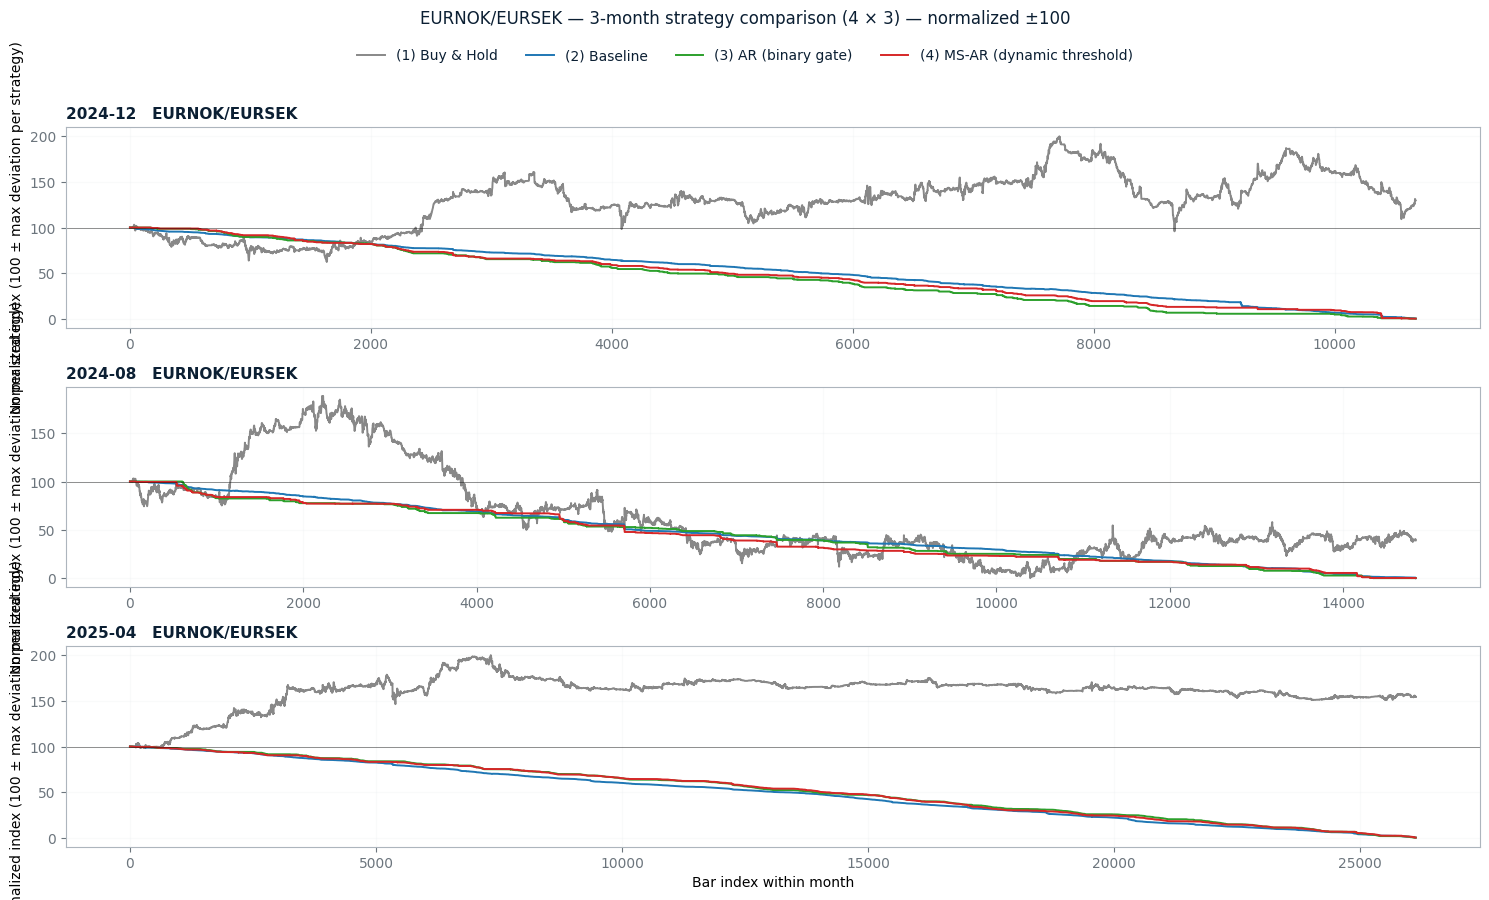

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_202412_strategy_panel.pdf


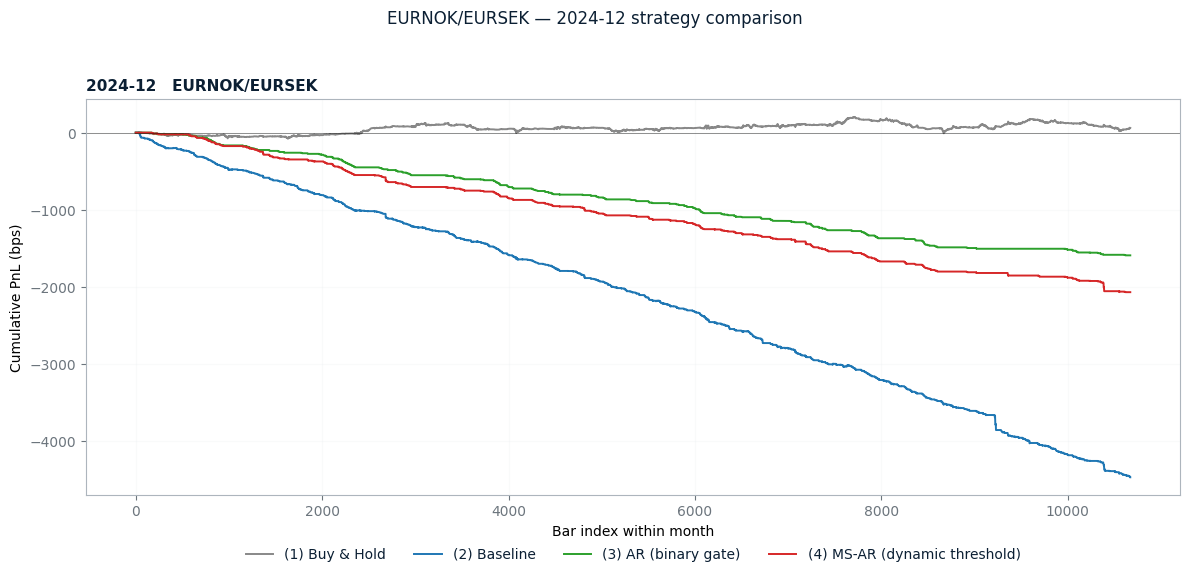

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_202408_strategy_panel.pdf


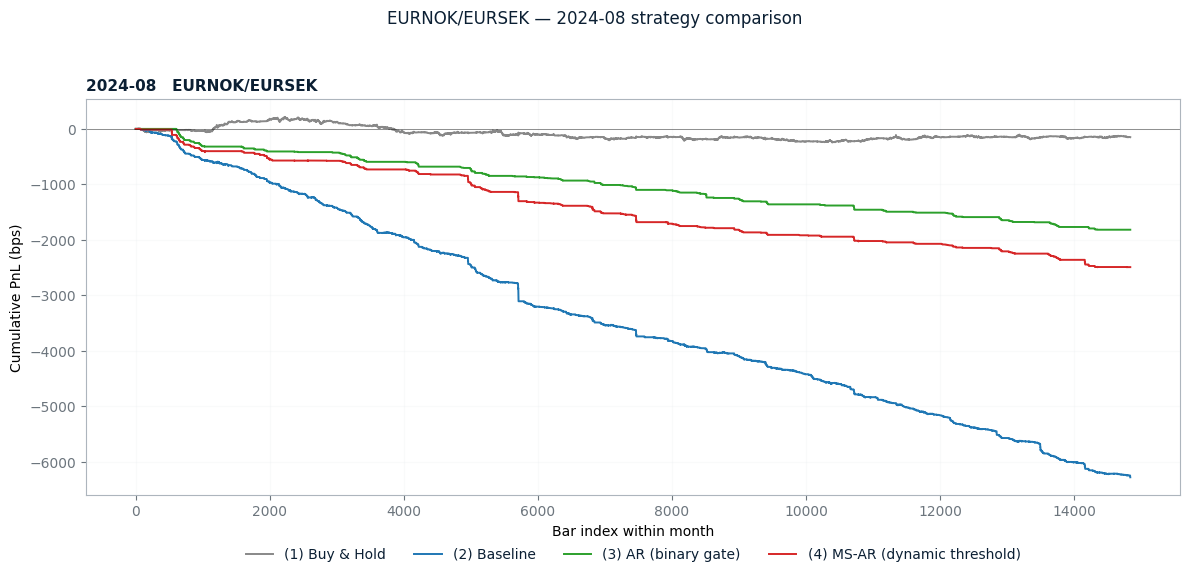

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_202504_strategy_panel.pdf


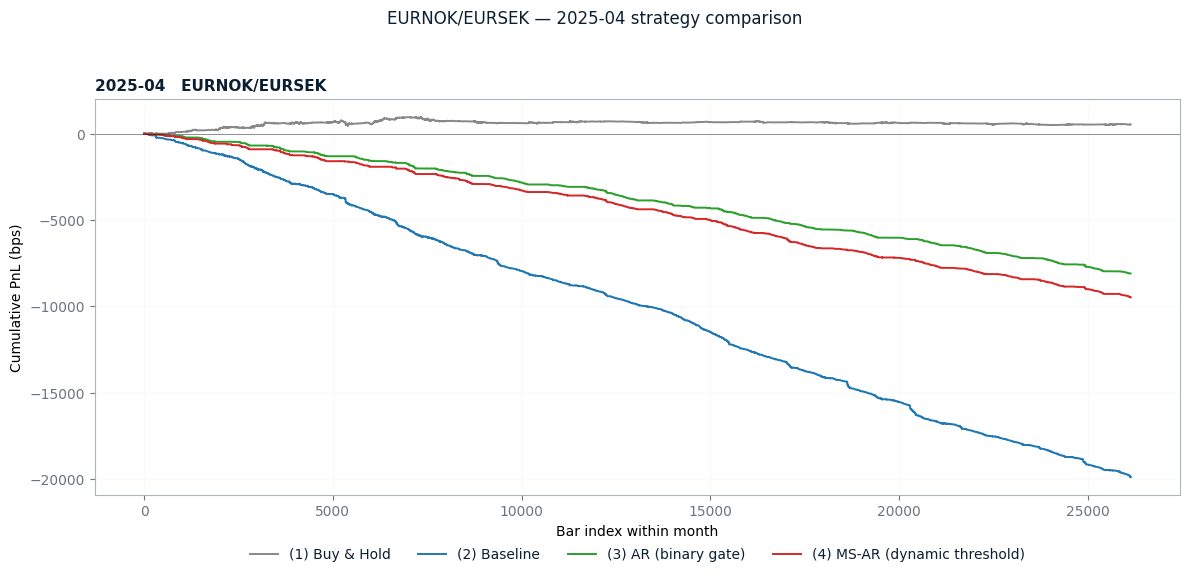

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_202412_strategy_panel_symlog.pdf


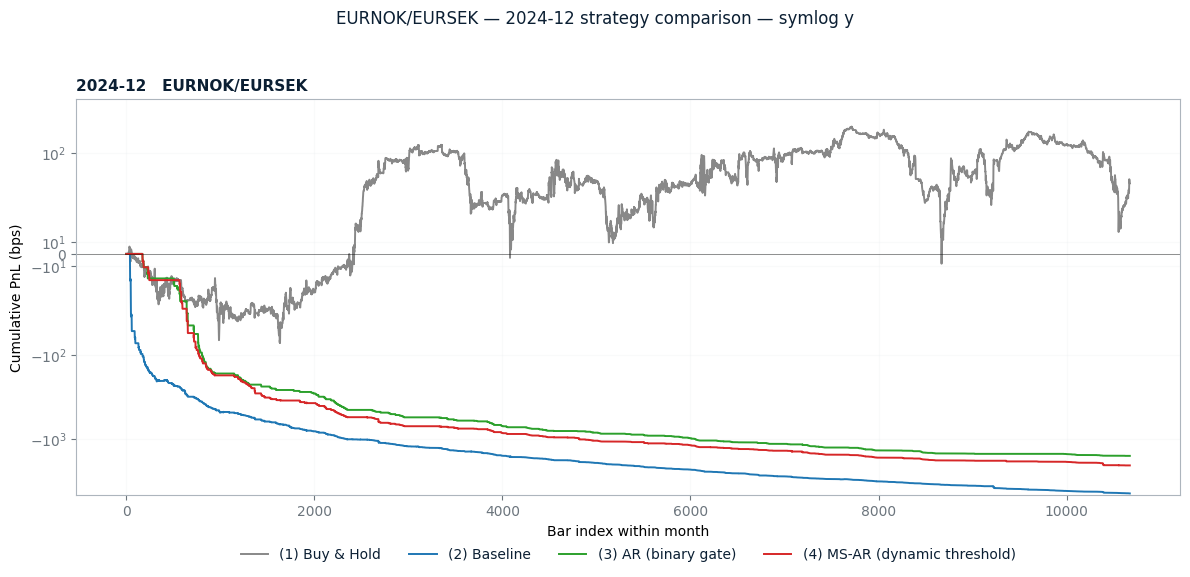

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_202408_strategy_panel_symlog.pdf


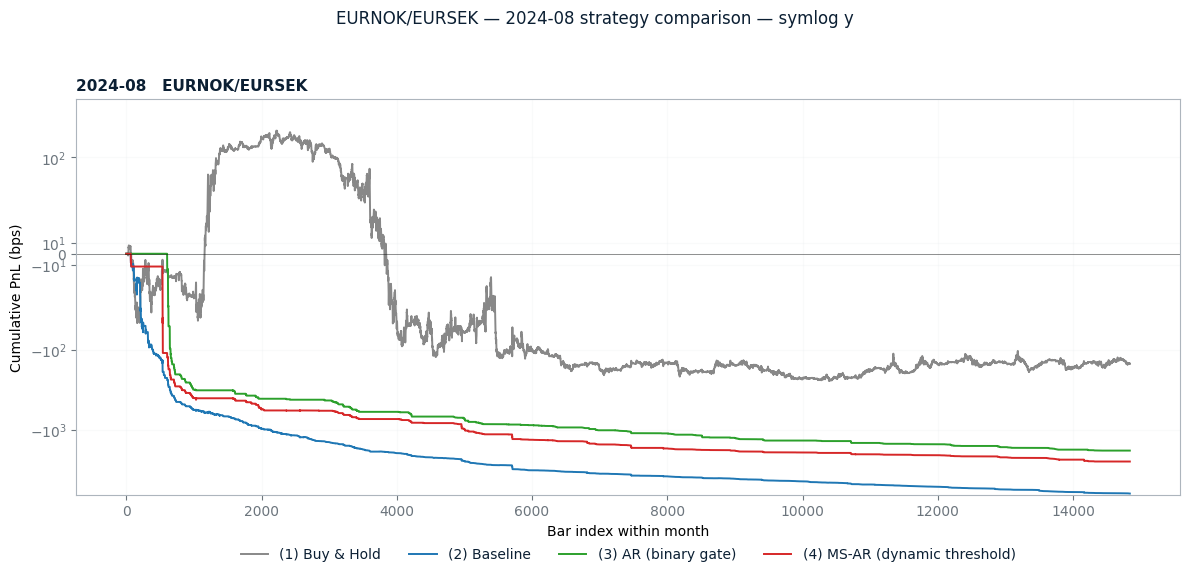

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_202504_strategy_panel_symlog.pdf


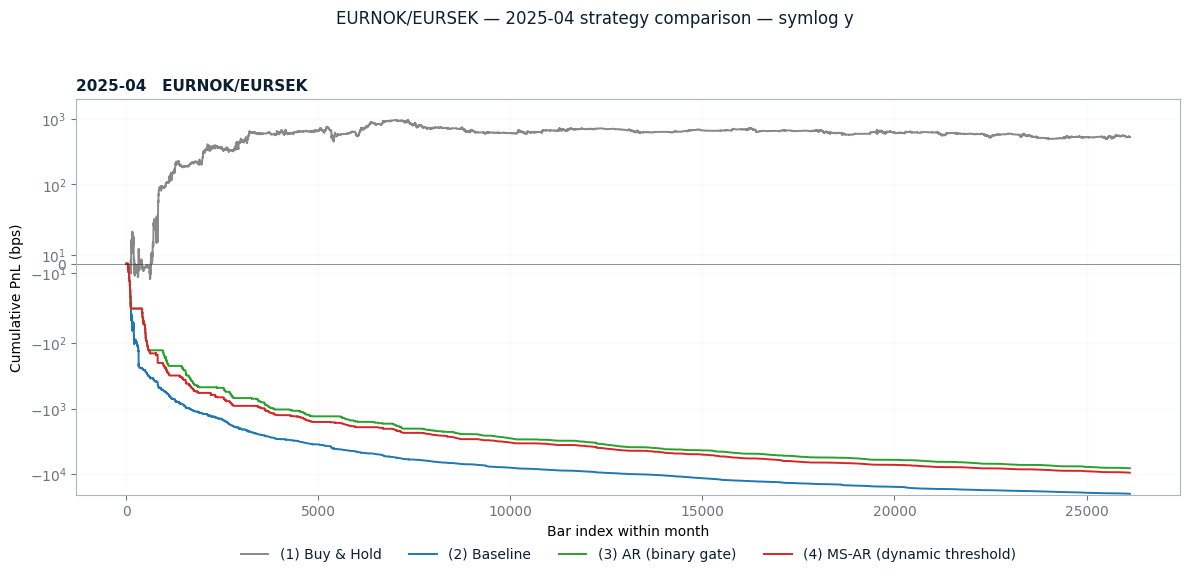

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_202412_strategy_panel_norm100.pdf


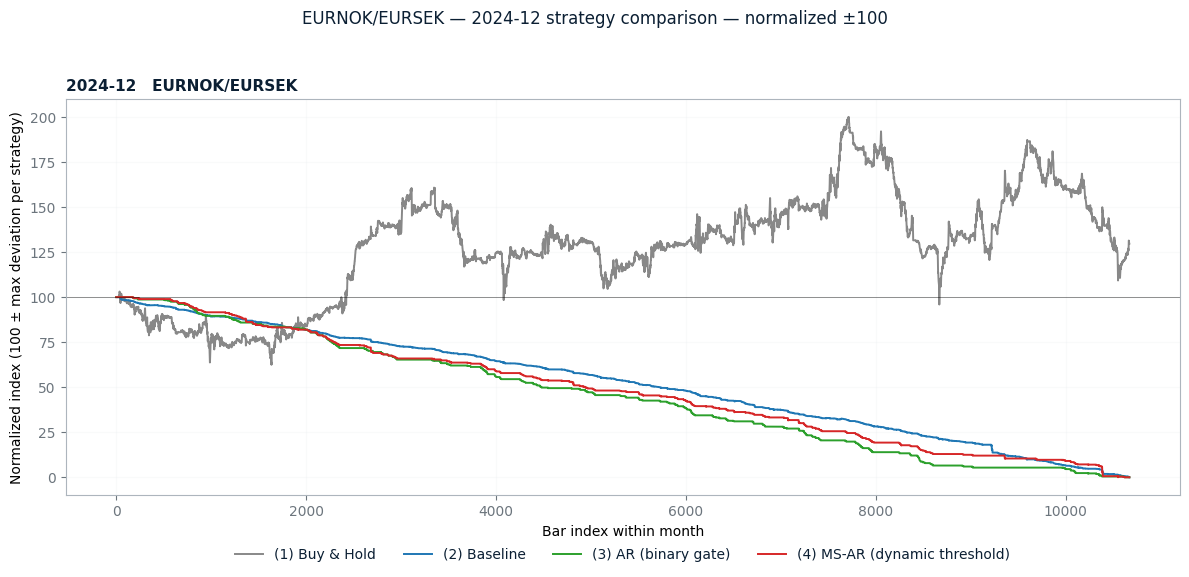

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_202408_strategy_panel_norm100.pdf


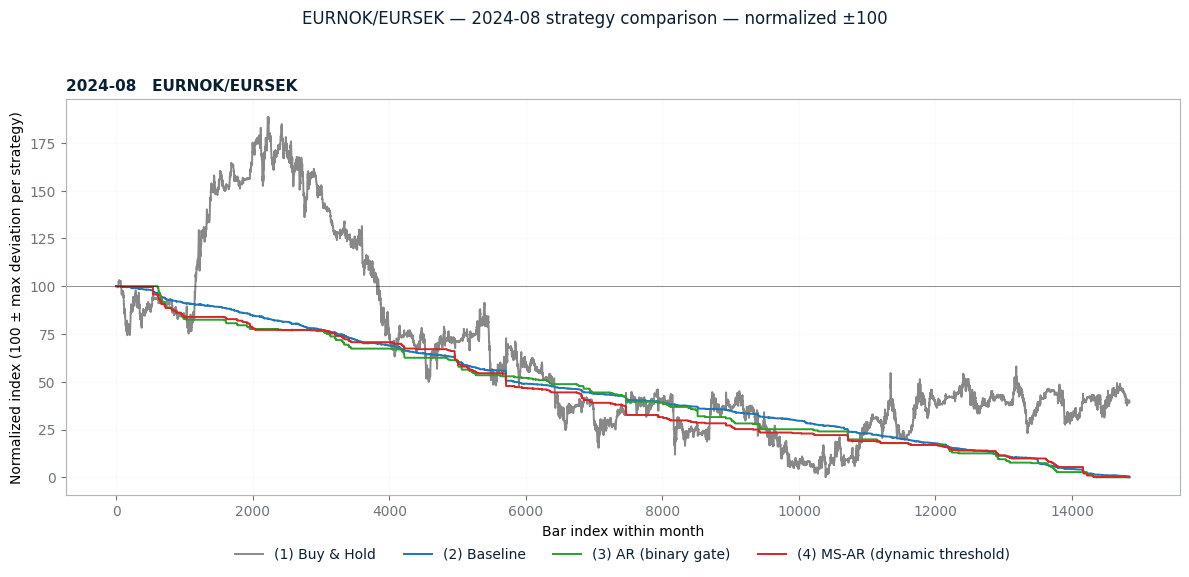

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_202504_strategy_panel_norm100.pdf


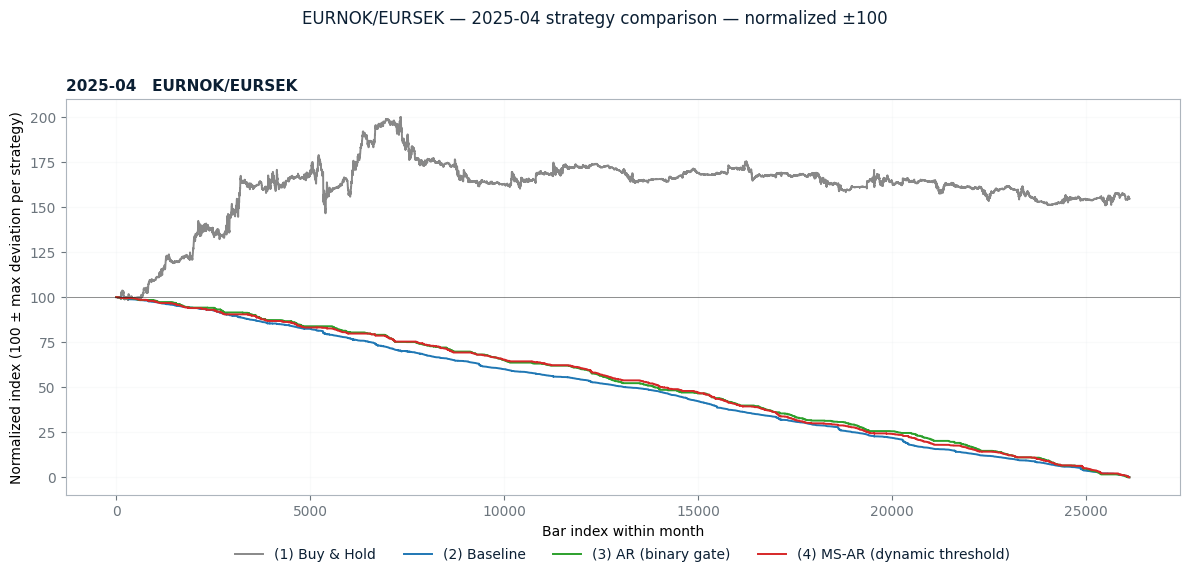

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_BuyHold_by_month_overlay.pdf


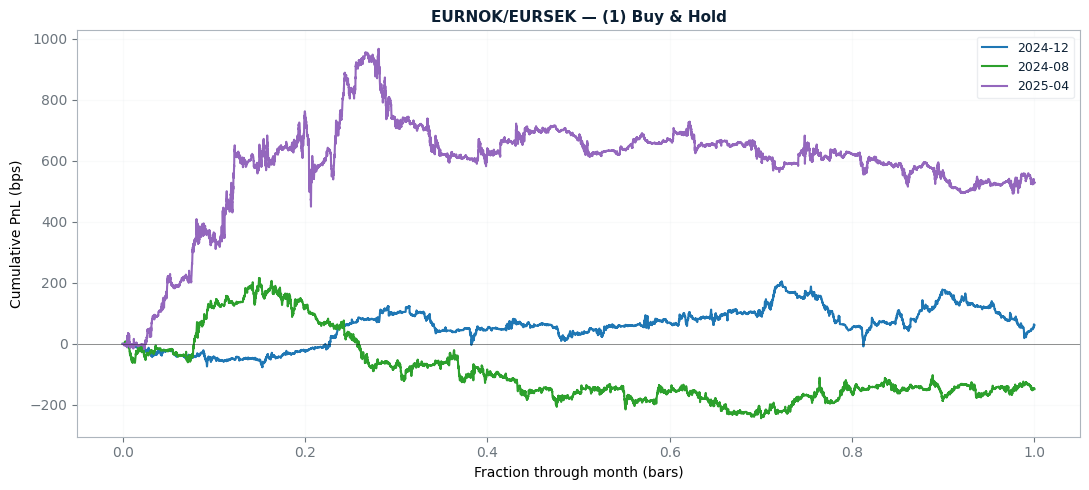

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_Baseline_by_month_overlay.pdf


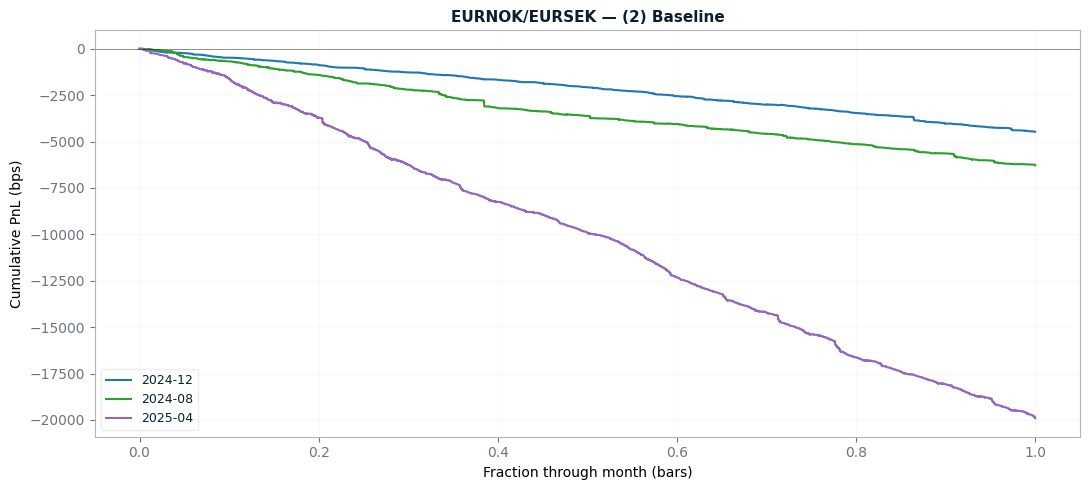

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_AR_by_month_overlay.pdf


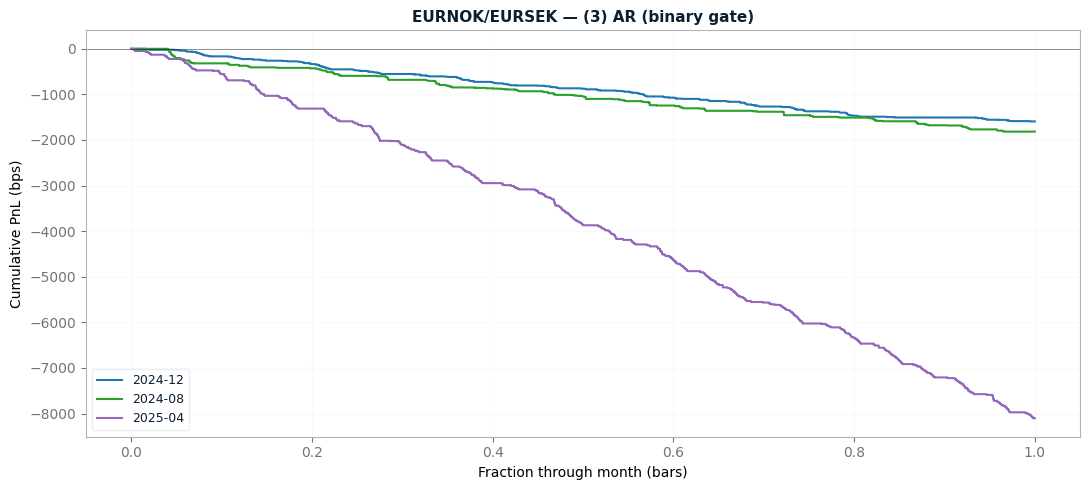

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_MS_AR_by_month_overlay.pdf


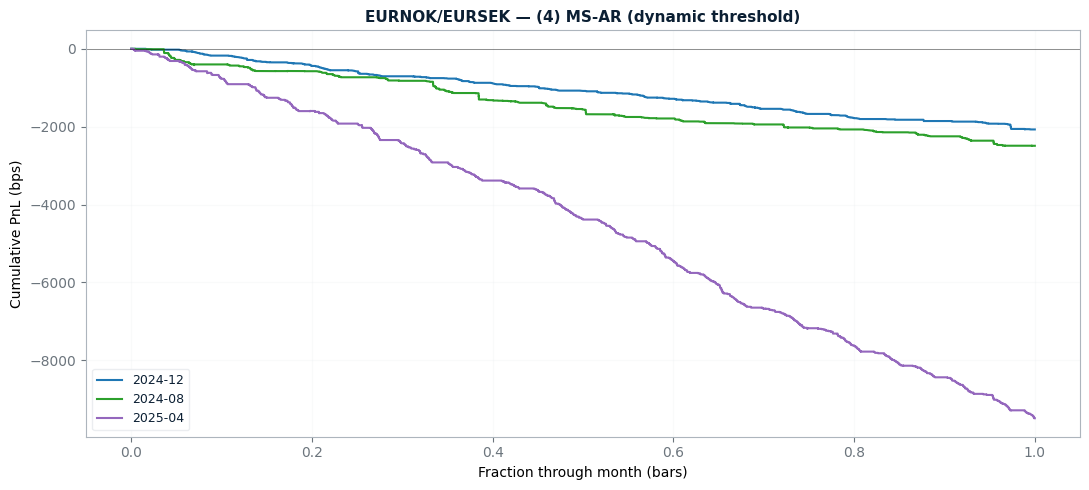

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_BuyHold_by_month_overlay_symlog.pdf


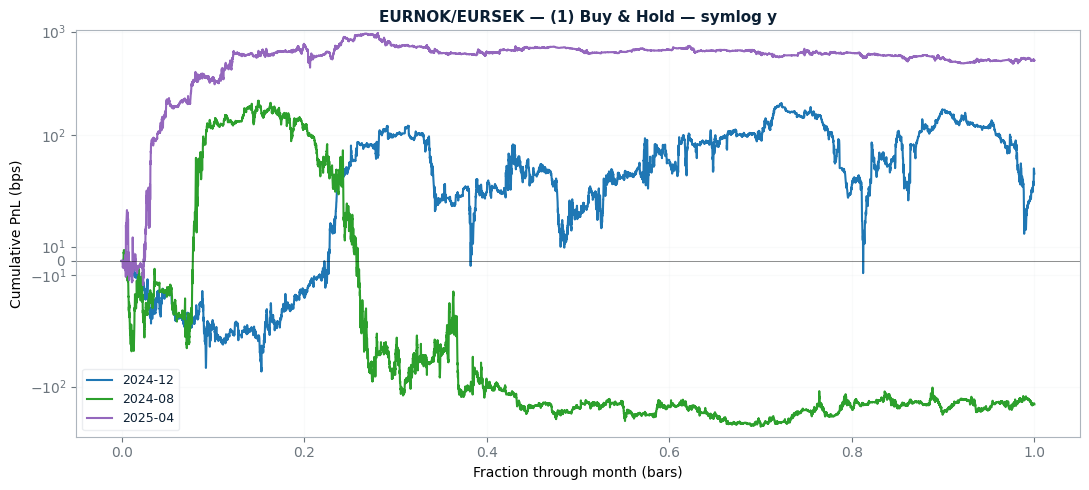

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_Baseline_by_month_overlay_symlog.pdf


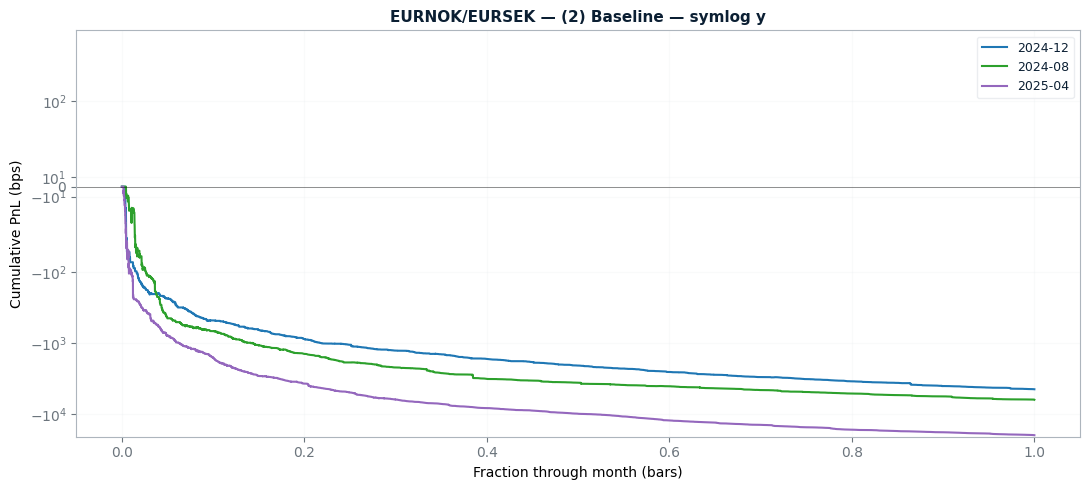

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_AR_by_month_overlay_symlog.pdf


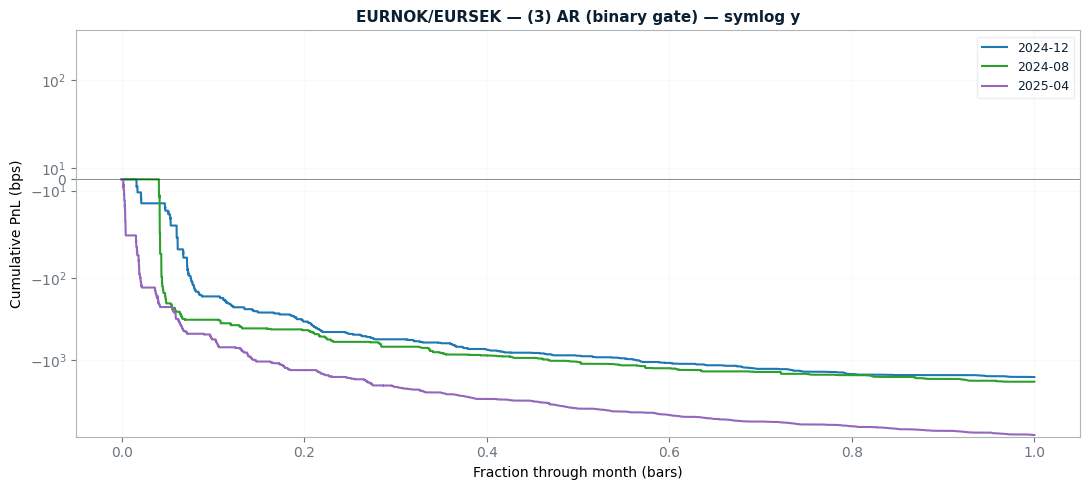

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_MS_AR_by_month_overlay_symlog.pdf


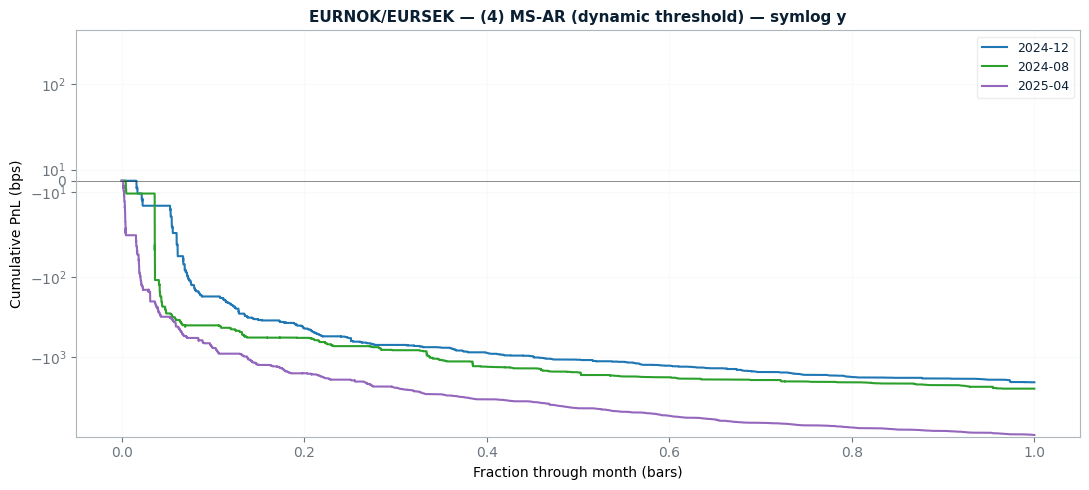

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_BuyHold_by_month_overlay_norm100.pdf


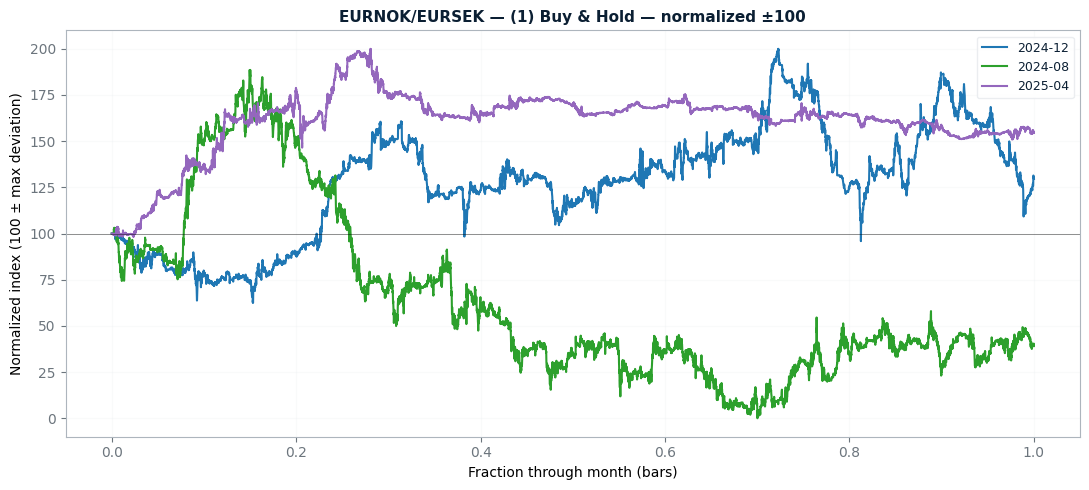

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_Baseline_by_month_overlay_norm100.pdf


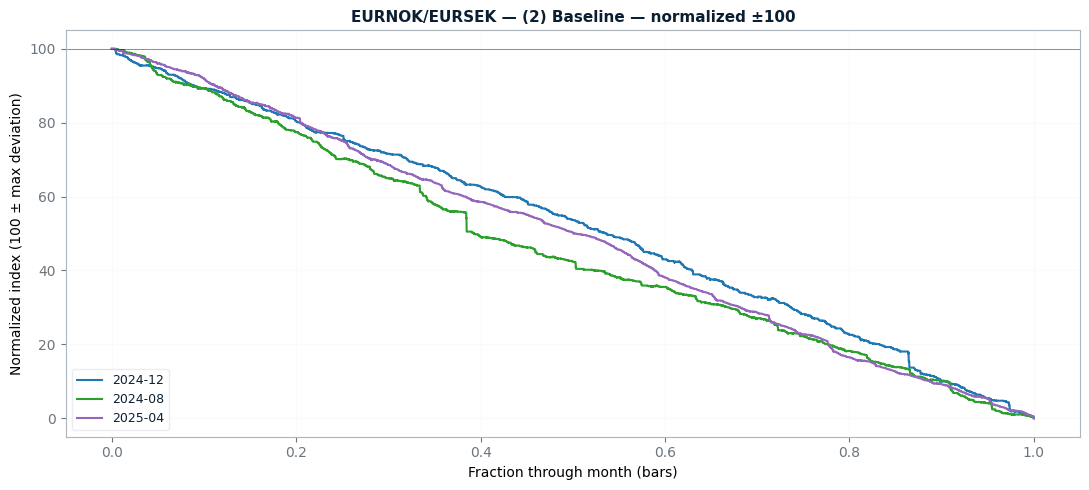

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_AR_by_month_overlay_norm100.pdf


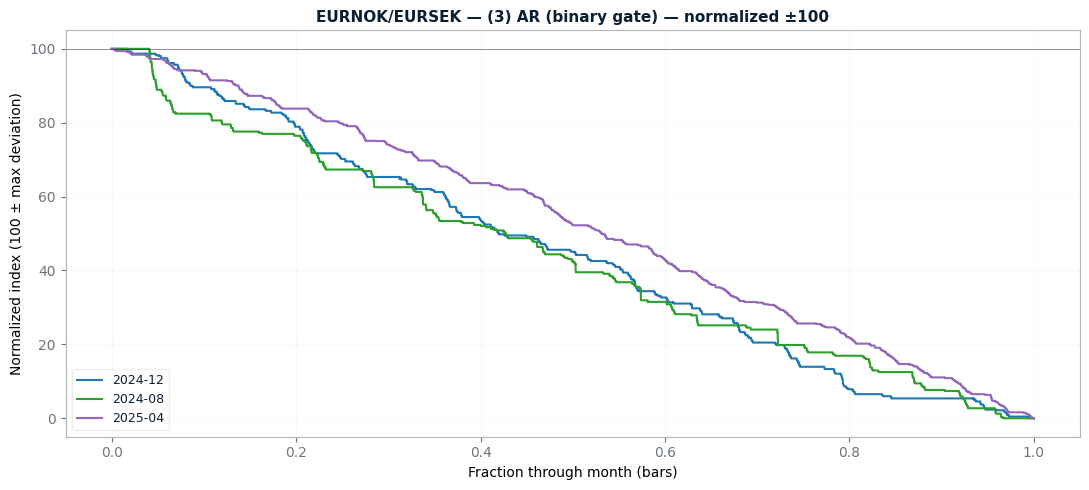

saved -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/plots/EURNOK_EURSEK/EURNOK_EURSEK_MS_AR_by_month_overlay_norm100.pdf


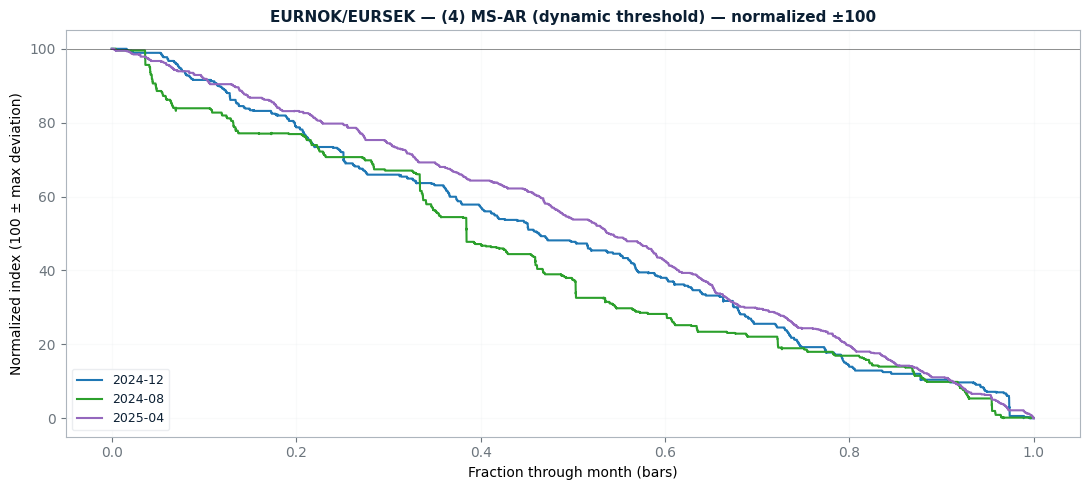

In [8]:
import matplotlib.pyplot as plt

STRAT_LABELS = {
    'BuyHold':  '(1) Buy & Hold',
    'Baseline': '(2) Baseline',
    'AR':       '(3) AR (binary gate)',
    'MS_AR':    '(4) MS-AR (dynamic threshold)',
}
STRAT_COLOURS = {
    'BuyHold':  '#888888',
    'Baseline': '#1f77b4',
    'AR':       '#2ca02c',
    'MS_AR':    '#d62728',
}


def _cum_bps_arrays(bt):
    out = {}
    for s in STRAT_LABELS:
        out[s] = bt[f'Return_{s}'].fillna(0).cumsum().values * 1e4
    return out


def _normalize_band_around_100(cum_bps):
    # Map cumulative path to ~[0,200] with start at 100; peak = max |Δ from first bar|.
    arr = np.asarray(cum_bps, dtype=float)
    offset = arr - arr[0]
    peak = np.nanmax(np.abs(offset))
    if not np.isfinite(peak) or peak < 1e-12:
        return np.full_like(arr, 100.0)
    return 100.0 + (offset / peak) * 100.0


def _plot_strategy_panel(ax, m, bt, *, variant='linear'):
    # variant: linear | symlog | norm100
    t = np.arange(len(bt))
    raw = _cum_bps_arrays(bt)

    if variant == 'norm100':
        series = {s: _normalize_band_around_100(raw[s]) for s in STRAT_LABELS}
        ref = 100.0
        y_label = 'Normalized index (100 ± max deviation per strategy)'
    else:
        series = raw
        ref = 0.0
        y_label = 'Cumulative PnL (bps)'

    for s in STRAT_LABELS:
        ax.plot(t, series[s], label=STRAT_LABELS[s], color=STRAT_COLOURS[s], linewidth=1.4)

    ax.axhline(ref, color='black', linewidth=0.6, alpha=0.5)
    ax.set_title(f'{m[:4]}-{m[4:]}   {PAIR_A}/{PAIR_B}', loc='left', fontsize=11)
    ax.set_ylabel(y_label)
    ax.grid(True, alpha=0.25)

    if variant == 'symlog':
        ax.set_yscale('symlog', linthresh=80.0, linscale=1.0)


def _decorate_stacked(fig, axes, variant):
    axes[-1].set_xlabel('Bar index within month')
    handles, labels = axes[0].get_legend_handles_labels()
    suffix = {'linear': '', 'symlog': ' — symlog y', 'norm100': ' — normalized ±100'}[variant]
    fig.suptitle(
        f'{PAIR_A}/{PAIR_B} — 3-month strategy comparison (4 × 3){suffix}',
        fontsize=12, y=0.995,
    )
    fig.legend(
        handles, labels,
        loc='upper center', bbox_to_anchor=(0.5, 0.965),
        ncol=4, frameon=False, fontsize=10,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.94])


def _decorate_monthly(fig_m, ax_m, m, variant):
    ax_m.set_xlabel('Bar index within month')
    ax_m.legend(
        loc='upper center', bbox_to_anchor=(0.5, -0.10),
        ncol=4, frameon=False, fontsize=10,
    )
    suffix = {'linear': '', 'symlog': ' — symlog y', 'norm100': ' — normalized ±100'}[variant]
    fig_m.suptitle(
        f'{PAIR_A}/{PAIR_B} — {m[:4]}-{m[4:]} strategy comparison{suffix}',
        fontsize=12, y=0.995,
    )
    fig_m.tight_layout(rect=[0, 0.03, 1, 0.96])


# ---- Stacked three-month figures (linear + symlog + normalized) ------------
for variant in ('linear', 'symlog', 'norm100'):
    fig, axes = plt.subplots(
        nrows=len(MONTHS), ncols=1,
        figsize=(15, 3.0 * len(MONTHS)),
        sharex=False,
    )
    if len(MONTHS) == 1:
        axes = [axes]

    for ax, m in zip(axes, MONTHS):
        _plot_strategy_panel(ax, m, runs[m][0], variant=variant)

    _decorate_stacked(fig, axes, variant)

    tag = '' if variant == 'linear' else f'_{variant}'
    out_pdf = PAIR_DIR / f'{PAIR_A}_{PAIR_B}_three_month_strategy_panel{tag}.pdf'
    fig.savefig(out_pdf, bbox_inches='tight')
    print(f'saved -> {out_pdf}')
    plt.show()


# ---- Per-month standalone PDFs (each variant) --------------------------------
for variant in ('linear', 'symlog', 'norm100'):
    for m in MONTHS:
        fig_m, ax_m = plt.subplots(figsize=(12, 6))
        _plot_strategy_panel(ax_m, m, runs[m][0], variant=variant)
        _decorate_monthly(fig_m, ax_m, m, variant)

        tag = '' if variant == 'linear' else f'_{variant}'
        out_pdf_m = PAIR_DIR / f'{PAIR_A}_{PAIR_B}_{m}_strategy_panel{tag}.pdf'
        fig_m.savefig(out_pdf_m, bbox_inches='tight')
        print(f'saved -> {out_pdf_m}')
        plt.show()


# ---- Individual-strategy overlays (months on fraction-of-month axis) ----------
MONTH_COLOURS = plt.cm.tab10(np.linspace(0, 0.45, len(MONTHS)))

for variant in ('linear', 'symlog', 'norm100'):
    for s in STRAT_LABELS:
        fig_i, ax_i = plt.subplots(figsize=(11, 5))
        for idx, m in enumerate(MONTHS):
            bt = runs[m][0]
            raw = _cum_bps_arrays(bt)[s]
            if variant == 'norm100':
                y = _normalize_band_around_100(raw)
                ref = 100.0
                y_label = 'Normalized index (100 ± max deviation)'
            else:
                y = raw
                ref = 0.0
                y_label = 'Cumulative PnL (bps)'
            t_frac = np.linspace(0.0, 1.0, len(bt))
            lbl = f'{m[:4]}-{m[4:]}'
            ax_i.plot(t_frac, y, label=lbl, color=MONTH_COLOURS[idx], linewidth=1.5)

        ax_i.axhline(ref, color='black', linewidth=0.6, alpha=0.5)
        suffix = {'linear': '', 'symlog': ' — symlog y', 'norm100': ' — normalized ±100'}[variant]
        ax_i.set_title(f'{PAIR_A}/{PAIR_B} — {STRAT_LABELS[s]}{suffix}', fontsize=11)
        ax_i.set_xlabel('Fraction through month (bars)')
        ax_i.set_ylabel(y_label)
        ax_i.legend(loc='best', fontsize=9)
        ax_i.grid(True, alpha=0.25)

        if variant == 'symlog':
            ax_i.set_yscale('symlog', linthresh=80.0, linscale=1.0)

        fig_i.tight_layout()
        tag = '' if variant == 'linear' else f'_{variant}'
        out_i = PAIR_DIR / f'{PAIR_A}_{PAIR_B}_{s}_by_month_overlay{tag}.pdf'
        fig_i.savefig(out_i, bbox_inches='tight')
        print(f'saved -> {out_i}')
        plt.show()


In [9]:
def annualised_sharpe(returns, ann_factor):
    r = returns.fillna(0)
    sd = r.std()
    return float(r.mean() / sd * np.sqrt(ann_factor)) if sd > 0 else 0.0


rows = []
for m, (bt, _, _) in runs.items():
    n_bars  = len(bt)
    n_days  = bt.index.normalize().unique().shape[0]
    bpd     = n_bars / max(n_days, 1)
    ann_fac = 252.0 * bpd            # 252 trading days × bars-per-day

    row = {'Month': m, 'BarsPerDay': round(bpd, 1), 'AnnFactor': int(ann_fac)}
    for s in ['BuyHold', 'Baseline', 'AR', 'MS_AR']:
        r = bt[f'Return_{s}']
        row[f'{s}_PnL_bps'] = float(r.fillna(0).sum() * 1e4)
        row[f'{s}_Sharpe']  = annualised_sharpe(r, ann_fac)
        row[f'{s}_Trades']  = int((bt[f'Target_{s}'].diff().abs() > 0).sum() / 2)
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Month')

print('\n=== PnL bps by month ===')
print(summary[[c for c in summary.columns if c.endswith('PnL_bps')]].round(1).to_string())

print('\n=== Sharpe (annualised on per-run bar density: 252 × bars/day) ===')
sharpe_cols = ['BarsPerDay', 'AnnFactor'] + [c for c in summary.columns if c.endswith('Sharpe')]
print(summary[sharpe_cols].round(2).to_string())

print('\n=== Round-trip trade counts ===')
print(summary[[c for c in summary.columns if c.endswith('Trades')]].to_string())

summary


=== PnL bps by month ===
        BuyHold_PnL_bps  Baseline_PnL_bps  AR_PnL_bps  MS_AR_PnL_bps
Month                                                               
202412             60.6           -4473.8     -1592.8        -2070.8
202408           -148.5           -6277.4     -1816.7        -2490.5
202504            527.7          -19906.4     -8103.5        -9487.3

=== Sharpe (annualised on per-run bar density: 252 × bars/day) ===
        BarsPerDay  AnnFactor  BuyHold_Sharpe  Baseline_Sharpe  AR_Sharpe  MS_AR_Sharpe
Month                                                                                  
202412       508.2     128076            1.17           -67.58     -56.96        -47.77
202408       674.6     169996           -1.97           -61.50     -43.54        -35.76
202504      1187.7     299295            4.20          -120.25    -100.00        -99.70

=== Round-trip trade counts ===
        BuyHold_Trades  Baseline_Trades  AR_Trades  MS_AR_Trades
Month                  

,BarsPerDay,AnnFactor,BuyHold_PnL_bps,BuyHold_Sharpe,BuyHold_Trades,Baseline_PnL_bps,Baseline_Sharpe,Baseline_Trades,AR_PnL_bps,AR_Sharpe,AR_Trades,MS_AR_PnL_bps,MS_AR_Sharpe,MS_AR_Trades
Month,,,,,,,,,,,,,,
202412,508.2,128076,60.582507,1.173988,0,-4473.829975,-67.582804,435,-1592.836968,-56.961331,158,-2070.780187,-47.766118,181
202408,674.6,169996,-148.509129,-1.971296,0,-6277.415575,-61.497097,606,-1816.721701,-43.542301,137,-2490.509813,-35.760377,158
202504,1187.7,299295,527.697442,4.200883,0,-19906.386828,-120.248358,1116,-8103.486334,-100.001284,495,-9487.279517,-99.696974,545


### Per-day regime parameters

Each row in `runs[m][1]` is the per-day fit summary: bar count, $\beta$, regime $\sigma$, regime $\rho$, regime means and transition probabilities. Useful for sanity-checking the HMM and for the paper's tables.


In [10]:
for m, (_, params, _) in runs.items():
    print(f'\n=== {m}  per-day fits ===')
    print(params.round(4).to_string())



=== 202412  per-day fits ===
            Bars    Beta   Alpha  MR_Sigma  DR_Sigma  MR_Rho  DR_Rho   MR_Mu   DR_Mu  P_MR_MR  P_DR_DR  Safe_Variance  Danger_Variance  Safe_Mean  Danger_Mean  P_Safe_Safe  P_Danger_Danger
Date                                                                                                                                                                                        
2024-12-02   656  0.8649  0.3399    0.0001    0.0002  0.8402  0.8924 -0.0001 -0.0005   0.9266      NaN            0.0              0.0    -0.0001      -0.0005       0.9266              NaN
2024-12-03   720  0.4892  1.2556    0.0001    0.0002  0.8769  0.9140 -0.0001  0.0004   0.9817      NaN            0.0              0.0    -0.0001       0.0004       0.9817              NaN
2024-12-04   676  0.7595  0.5990    0.0001    0.0002  0.8934  0.8798  0.0001  0.0002   0.9177      NaN            0.0              0.0     0.0001       0.0002       0.9177              NaN
2024-12-05   656  1.5183 

## Daily trading ledger (three evaluation months)

Each row is one **calendar date** present anywhere in the tick-clock index after concatenating all runs in `MONTHS`. The four strategy columns each show **what happened intraday** (dominant side from the mean of `Target_*`, plus approximate completed round-trips from bar-to-bar position changes) and **net PnL that day** in **basis points** (sum of `Return_*`, consistent with the tearsheet).

Weekends, holidays, and dates outside the three downloaded months do not appear as rows.

---

In [11]:
STRATS = ['BuyHold', 'Baseline', 'AR', 'MS_AR']
STRAT_HEADERS = {
    'BuyHold': '(1) Buy&Hold',
    'Baseline': '(2) Baseline',
    'AR': '(3) AR',
    'MS_AR': '(4) MS-AR',
}


def _activity_for_day(sub: pd.DataFrame, target_col: str) -> str:
    x = sub[target_col].fillna(0.0).to_numpy()
    if len(x) == 0:
        return 'no bars'
    flips = int(np.sum(np.abs(np.diff(x)) > 1e-12))
    rt = flips // 2
    mx = float(np.mean(x))
    if mx > 0.25:
        side = 'long'
    elif mx < -0.25:
        side = 'short'
    else:
        side = 'flat/mixed'
    if rt == 0:
        return f'{side}, no flips'
    return f'{side}, ~{rt} round-trips'


def daily_trading_ledger(runs: dict, months: list) -> pd.DataFrame:
    parts = []
    for m in months:
        bt = runs[m][0]
        frag = bt.copy()
        frag['_month_key'] = m
        parts.append(frag)
    all_bt = pd.concat(parts)
    all_bt['_cal_day'] = pd.to_datetime(all_bt.index).normalize()

    rows = []
    for day in sorted(all_bt['_cal_day'].unique()):
        slice_ = all_bt[all_bt['_cal_day'] == day]
        mk = str(slice_['_month_key'].iloc[0])
        row = {'calendar_date': pd.Timestamp(day).date(), 'month': mk}
        for s in STRATS:
            pnl_bps = float(slice_[f'Return_{s}'].fillna(0.0).sum() * 1e4)
            act = _activity_for_day(slice_, f'Target_{s}')
            row[STRAT_HEADERS[s]] = f'{act}; {pnl_bps:+.2f} bps'
        rows.append(row)
    return pd.DataFrame(rows)


ledger_df = daily_trading_ledger(runs, MONTHS)
print(f'\n=== Daily trading ledger — {PAIR_A}/{PAIR_B} ===\n')

try:
    from IPython.display import display
    with pd.option_context('display.max_rows', None, 'display.width', None, 'display.max_colwidth', None):
        display(ledger_df)
except Exception:
    pd.set_option('display.max_rows', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)
    print(ledger_df.to_string(index=False))

print('\nTotals over full multi-month sample (bps):')
for s in STRATS:
    tot = float(sum(runs[m][0][f'Return_{s}'].fillna(0).sum() * 1e4 for m in MONTHS))
    print(f"  {STRAT_HEADERS[s]}: {tot:+.2f}")


=== Daily trading ledger — EURNOK/EURSEK ===



,calendar_date,month,(1) Buy&Hold,(2) Baseline,(3) AR,(4) MS-AR
0,2024-08-01,202408,"long, no flips; -18.20 bps","flat/mixed, ~29 round-trips; -446.12 bps","flat/mixed, ~7 round-trips; -201.46 bps","flat/mixed, ~8 round-trips; -284.68 bps"
1,2024-08-02,202408,"long, no flips; +145.51 bps","flat/mixed, ~36 round-trips; -293.29 bps","flat/mixed, ~12 round-trips; -150.88 bps","flat/mixed, ~13 round-trips; -145.72 bps"
2,2024-08-05,202408,"long, no flips; -59.15 bps","flat/mixed, ~65 round-trips; -839.32 bps","flat/mixed, ~13 round-trips; -159.51 bps","flat/mixed, ~16 round-trips; -218.97 bps"
3,2024-08-06,202408,"long, no flips; -129.52 bps","flat/mixed, ~45 round-trips; -546.57 bps","flat/mixed, ~10 round-trips; -168.80 bps","flat/mixed, ~11 round-trips; -163.92 bps"
4,2024-08-07,202408,"long, no flips; -0.51 bps","flat/mixed, ~37 round-trips; -466.82 bps","flat/mixed, ~6 round-trips; -112.94 bps","flat/mixed, ~8 round-trips; -235.61 bps"
5,2024-08-08,202408,"long, no flips; -16.30 bps","flat/mixed, ~24 round-trips; -513.76 bps","flat/mixed, ~7 round-trips; -63.19 bps","flat/mixed, ~9 round-trips; -253.59 bps"
6,2024-08-09,202408,"long, no flips; -40.90 bps","flat/mixed, ~21 round-trips; -143.92 bps","flat/mixed, ~7 round-trips; -36.39 bps","flat/mixed, ~7 round-trips; -44.56 bps"
7,2024-08-12,202408,"long, no flips; -24.75 bps","flat/mixed, ~21 round-trips; -238.40 bps","flat/mixed, ~7 round-trips; -81.19 bps","flat/mixed, ~8 round-trips; -138.30 bps"
8,2024-08-13,202408,"long, no flips; -3.94 bps","flat/mixed, ~23 round-trips; -251.14 bps","flat/mixed, ~10 round-trips; -124.40 bps","flat/mixed, ~11 round-trips; -195.03 bps"
9,2024-08-14,202408,"long, no flips; +4.43 bps","flat/mixed, ~12 round-trips; -82.69 bps","flat/mixed, ~1 round-trips; -7.49 bps","flat/mixed, ~2 round-trips; -27.24 bps"



Totals over full multi-month sample (bps):
  (1) Buy&Hold: +439.77
  (2) Baseline: -30657.63
  (3) AR: -11513.05
  (4) MS-AR: -14048.57


## Discussion

**EURNOK/EURSEK is the wide-spread negative control.** The Scandi-cross has structurally wider half-spreads than the major pairs (typically 5–10× wider). At $L=500$ tick-synced bars the per-trade cost on this pair is roughly **12–15 bps for AR**, compared with **~1–2 bps on GBPUSD/EURUSD**. As a result the strategies cannot survive on this pair regardless of how cleanly the HMM filters regimes. We keep these results in the paper because they function as a *cost-dominance robustness check*: the same machinery that almost breaks even on GBPEUR is overwhelmed here purely by widening the half-spread, confirming that the binding constraint is microstructure cost and not signal quality. The headline strategy ranking should be drawn from GBPUSD/EURUSD and AUDUSD/NZDUSD; EURNOK/EURSEK belongs in the appendix as a wide-spread sanity check.

**MS-AR vs AR.** Same pattern as the majors only louder: MS-AR is consistently *worse* than AR (e.g. 2025-04: MS-AR 545 round-trips vs AR 496, MS-AR loss 1359 bps deeper). The continuous $\gamma$-weighted threshold admits more entries on this high-volatility pair, and every additional entry is a guaranteed loser at these spreads. The binary gate (paper §4.8 eqs. 27–28) is the right construction; the continuous version (eqs. 29–30) is not justified at this resolution.

**Sharpe scaling.** The annualisation factor is now per run (`252 × bars/day`) and reported in the table alongside the Sharpe values. EURNOK/EURSEK is the densest pair (≈500–1200 bars/day depending on month), so the magnitude correction vs the prior global `252 × 24 × 60` is the smallest — but the sign and ranking are still unchanged.